# 06 — Control Generation Audit

This notebook performs controlled signal-generation tests to diagnose whether the current 32 s BBH simulations contain mass-dependent information before adding detector noise and full preprocessing.

The goal is to isolate where the problem appears:

1. signal-only projected waveforms;
2. signal-only fixed-duration segments;
3. high-SNR noisy signals;
4. standard noisy and processed signals.

We start with the cleanest possible case: signal-only fixed-duration segments for mass groups 20+20, 40+40, 60+60 and 80+80.

In [43]:
from pathlib import Path
import sys
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
from pathlib import Path
import sys

def find_project_root(start: Path | None = None, marker: str = "src") -> Path:
    """
    Walk upwards from `start` until finding a directory containing `marker`.

    For this project, the repository root should contain:
        src/
        notebooks/
        configs/
        scripts/
    """
    if start is None:
        start = Path.cwd()

    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / marker).is_dir():
            return candidate

    raise RuntimeError(
        f"Could not find project root containing '{marker}/' starting from {start}"
    )


PROJECT_ROOT = find_project_root()
print("PROJECT_ROOT:", PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("src exists:", (PROJECT_ROOT / "src").exists())

PROJECT_ROOT: /home/victor/gw/cbc_pe
src exists: True


In [45]:
from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.sampling import PriorConfig, ParameterSampler
from src.dataset import DatasetBuilder
from src.processing import SignalProcessor
from src.snr import compute_network_optimal_snr


## 1. Simulation configuration

We use the same 32 s configuration as the HDF5 files given to the supervisor.

At this stage we keep the standard physical setup:

- BBH regime;
- 32 s strain segment;
- 4096 Hz sampling frequency;
- SEOBNRv4_opt waveform;
- low-frequency cutoff at 30 Hz;
- target network SNR range [10, 25].

However, the first diagnostic step will inspect the signal-only segments before adding noise.

In [46]:
config = SimulationConfig(
    simulation_regime="BBH",
    waveform_family="IMR",

    sampling_frequency=4096.0,
    duration=32.0,

    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",

    target_network_snr_range=(10.0, 25.0),
    snr_relative_tolerance=0.05,
    snr_on_truncated_signal=True,

    truncation_policy="keep_last_segment",
    required_final_duration=1.0,

    safe_margin_start=0.0,
    safe_margin_end=0.0,

    processing_context_start_samples=1664,
    processing_context_end_samples=1664,
)

print("duration:", config.duration)
print("sampling_frequency:", config.sampling_frequency)
print("length:", config.length)
print("delta_t:", config.delta_t)
print("delta_f:", config.delta_f)
print("processing_length:", config.processing_length)

duration: 32.0
sampling_frequency: 4096.0
length: 131072
delta_t: 0.000244140625
delta_f: 0.03125
processing_length: 134400


## 2. Builder for controlled generation

We create a `DatasetBuilder` mostly to reuse the same waveform, projection, windowing, injection and SNR machinery as the production pipeline.

For this first audit we will use the internal `_build_projected_signal_network` method. This is acceptable for diagnosis because we want access to intermediate signal-only objects.

In [47]:
detector_names = ["H1", "L1", "V1"]

signal_processor_kwargs = {
    "whitening_method": "psd",
    "apply_highpass": True,
    "apply_lowpass": True,
    "apply_standardization": False,
    "output_mode": "crop_to_config",

    "whitening_low_frequency_cutoff": 30.0,
    "whitening_max_filter_duration": 0.5,
    "whitening_trunc_method": "hann",

    "highpass_frequency": 30.0,
    "lowpass_frequency": 512.0,

    "fir_order": 256,
    "fir_beta": 5.0,
    "remove_corrupted": True,
}

builder = DatasetBuilder.from_config(
    config=config,
    detector_names=detector_names,
    signal_processor_kwargs=signal_processor_kwargs,
    label_transformer_kwargs={},
    parameter_sampler_kwargs={
        "regime": "BBH",
        "fixed": {},
    },
    rng=np.random.default_rng(1234),
)

builder

## 3. Controlled parameter generation

We generate controlled BBH parameters for four equal-mass groups:

- 20+20
- 40+40
- 60+60
- 80+80

Spins are fixed to zero. Extrinsic parameters are sampled randomly to preserve variability within each mass group.

In [48]:
def sample_params_for_mass_group(
    mass,
    n_samples,
    seed,
    distance_range=(200.0, 5000.0),
):
    """
    Sample CBC parameters for one equal-mass BBH group.

    Masses and aligned spins are fixed.
    Extrinsic parameters and initial distance are sampled.
    """
    prior = PriorConfig.bbh(
        fixed_parameters={
            "mass_1": float(mass),
            "mass_2": float(mass),
            "spin_1z": 0.0,
            "spin_2z": 0.0,
        }
    )

    # Keep default distance range unless explicitly changed.
    prior = PriorConfig(
        regime=prior.regime,
        component_mass_range=prior.component_mass_range,
        distance_range=distance_range,
        spin_1z_range=prior.spin_1z_range,
        spin_2z_range=prior.spin_2z_range,
        fixed_parameters=prior.fixed_parameters,
    )

    sampler = ParameterSampler(
        prior_config=prior,
        rng=np.random.default_rng(seed),
    )

    return sampler.sample_many(n_samples)

In [49]:
mass_groups = [20.0, 40.0, 60.0, 80.0]
n_per_mass = 20

all_params = []
all_mass_labels = []

for i, mass in enumerate(mass_groups):
    params_group = sample_params_for_mass_group(
        mass=mass,
        n_samples=n_per_mass,
        seed=1000 + i,
    )

    all_params.extend(params_group)
    all_mass_labels.extend([mass] * n_per_mass)

all_mass_labels = np.asarray(all_mass_labels, dtype=float)

print("number of parameter objects:", len(all_params))
print("mass label counts:")
print(pd.Series(all_mass_labels).value_counts().sort_index())

number of parameter objects: 80
mass label counts:
20.0    20
40.0    20
60.0    20
80.0    20
Name: count, dtype: int64


In [50]:
param_rows = []

for mass_label, p in zip(all_mass_labels, all_params):
    param_rows.append({
        "mass_group": mass_label,
        "mass_1": p.mass_1,
        "mass_2": p.mass_2,
        "distance": p.distance,
        "inclination": p.inclination,
        "ra": p.ra,
        "dec": p.dec,
        "spin_1z": p.spin_1z,
        "spin_2z": p.spin_2z,
        "chirp_mass": p.chirp_mass,
        "total_mass": p.total_mass,
        "chi_eff": p.chi_eff,
    })

params_df = pd.DataFrame(param_rows)
params_df.groupby("mass_group")[["mass_1", "mass_2", "chirp_mass", "total_mass", "chi_eff", "distance"]].describe()

mass_1                                          mass_2        ...  \
            count  mean  std   min   25%   50%   75%   max  count  mean  ...   
mass_group                                                               ...   
20.0         20.0  20.0  0.0  20.0  20.0  20.0  20.0  20.0   20.0  20.0  ...   
40.0         20.0  40.0  0.0  40.0  40.0  40.0  40.0  40.0   20.0  40.0  ...   
60.0         20.0  60.0  0.0  60.0  60.0  60.0  60.0  60.0   20.0  60.0  ...   
80.0         20.0  80.0  0.0  80.0  80.0  80.0  80.0  80.0   20.0  80.0  ...   

           chi_eff      distance                                        \
               75%  max    count         mean          std         min   
mass_group                                                               
20.0           0.0  0.0     20.0  2628.552993  1555.730388  245.636414   
40.0           0.0  0.0     20.0  2585.289185  1470.754751  301.709567   
60.0           0.0  0.0     20.0  2429.651007  1311.830817  361.605136   
80.0           0.0  0.0     20.0  2498.664617  1351.144232  429.013103   

                                                                
                    25%          50%          75%          max  
mass_group                                                      
20.0        1325.942573  2691.022097  4003.358012  4906.301854  
40.0        1386.288264  2668.424573  3460.439328  4923.761502  
60.0        1364.481078  2162.544225  3402.513036  4783.944040  
80.0        1718.174688  2334.187111  3299.239001  4922.440256  

[4 rows x 48 columns]

## 4. Build signal-only fixed-duration segments

For each parameter set we build the projected detector network and embed it into a fixed 32 s segment.

At this stage there is no detector noise.

The resulting arrays answer a clean diagnostic question:

Can the mass groups be distinguished from the projected signal morphology alone?

In [51]:
def build_signal_only_collection(
    builder,
    params_list,
    mass_labels,
    geocentric_coalescence_time=1126259462.0,
    placement_policy="random_contained",
):
    """
    Build signal-only fixed-duration detector segments using the same internal
    network-building machinery as DatasetBuilder.

    Returns
    -------
    X_signal : np.ndarray
        Shape (n_samples, n_detectors, n_time)
    metadata_rows : pd.DataFrame
        Per-sample diagnostic metadata.
    """
    X_list = []
    metadata_rows = []

    for i, (params, mass_label) in enumerate(zip(params_list, mass_labels)):
        network = builder._build_projected_signal_network(
            params=params,
            geocentric_coalescence_time=geocentric_coalescence_time,
            placement_policy=placement_policy,
        )

        X_i = np.stack(
            [np.asarray(network.signal_segments[det]) for det in builder.detector_names],
            axis=0,
        )

        X_list.append(X_i.astype(np.float32))

        metadata_rows.append({
            "index": i,
            "mass_group": mass_label,
            "mass_1": network.params.mass_1,
            "mass_2": network.params.mass_2,
            "distance": network.params.distance,
            "chirp_mass": network.params.chirp_mass,
            "total_mass": network.params.total_mass,
            "chi_eff": network.params.chi_eff,
            "network_snr": network.network_snr,
            "snr_H1": network.detector_snrs.get("H1", np.nan),
            "snr_L1": network.detector_snrs.get("L1", np.nan),
            "snr_V1": network.detector_snrs.get("V1", np.nan),
            "segment_start_time": network.placement.segment_start_time,
            "segment_end_time": network.placement.segment_end_time,
            "margin_before_signal": network.placement.margin_before_signal,
            "margin_after_signal": network.placement.margin_after_signal,
            "signal_network_duration": network.placement.signal_network_duration,
            "is_truncated": network.windowed.metadata.is_truncated,
            "used_window_duration": network.windowed.metadata.used_window_duration,
            "full_network_duration": network.windowed.metadata.full_network_duration,
        })

        if (i + 1) % 10 == 0 or i + 1 == len(params_list):
            print(f"Built {i + 1}/{len(params_list)} signal-only samples")

    X_signal = np.stack(X_list, axis=0)
    metadata_df = pd.DataFrame(metadata_rows)

    return X_signal, metadata_df

In [52]:
X_signal, signal_meta_df = build_signal_only_collection(
    builder=builder,
    params_list=all_params,
    mass_labels=all_mass_labels,
    geocentric_coalescence_time=1126259462.0,
    placement_policy="random_contained",
)

print("X_signal:", X_signal.shape)
signal_meta_df.head()

Built 10/80 signal-only samples
Built 20/80 signal-only samples
Built 30/80 signal-only samples
Built 40/80 signal-only samples
Built 50/80 signal-only samples
Built 60/80 signal-only samples
Built 70/80 signal-only samples
Built 80/80 signal-only samples
X_signal: (80, 3, 131072)


,index,mass_group,mass_1,mass_2,distance,chirp_mass,total_mass,chi_eff,network_snr,snr_H1,snr_L1,snr_V1,segment_start_time,segment_end_time,margin_before_signal,margin_after_signal,signal_network_duration,is_truncated,used_window_duration,full_network_duration
0,0,20.0,20.0,20.0,2460.520627,17.411011,40.0,0.0,8.603252,6.502856,5.619936,0.380958,1.126259e+09,1.126259e+09,0.729776,30.590780,0.679443,False,0.679443,0.679443
1,1,20.0,20.0,20.0,1392.188783,17.411011,40.0,0.0,14.395812,10.785911,8.672479,3.961265,1.126259e+09,1.126259e+09,19.409588,11.906086,0.684326,False,0.684326,0.684326
2,2,20.0,20.0,20.0,4878.866147,17.411011,40.0,0.0,3.985811,2.073338,3.161874,1.261153,1.126259e+09,1.126259e+09,2.404552,28.923573,0.671875,False,0.671875,0.671875
3,3,20.0,20.0,20.0,3572.801468,17.411011,40.0,0.0,6.146725,3.027149,3.394555,4.134682,1.126259e+09,1.126259e+09,23.130333,8.198525,0.671143,False,0.671143,0.671143
4,4,20.0,20.0,20.0,245.636414,17.411011,40.0,0.0,55.901644,39.203213,27.770063,28.581909,1.126259e+09,1.126259e+09,21.337563,9.999595,0.662842,False,0.662842,0.662842


In [53]:
signal_meta_df.groupby("mass_group")[["network_snr", "distance", "signal_network_duration", "used_window_duration"]].describe()

network_snr                                                       \
                 count       mean        std       min       25%        50%   
mass_group                                                                    
20.0              20.0  11.831193  12.854555  1.867558  3.915183   7.224190   
40.0              20.0  18.524877  23.950031  2.582629  5.825181   8.556168   
60.0              20.0  30.129353  43.841686  4.302513  9.721539  16.181028   
80.0              20.0  27.769641  28.223395  3.989589  9.668444  17.936299   

                                  distance               ...  \
                  75%         max    count         mean  ...   
mass_group                                               ...   
20.0        15.068109   55.901644     20.0  2628.552993  ...   
40.0        19.234602  104.437042     20.0  2585.289185  ...   
60.0        28.944424  191.345652     20.0  2429.651007  ...   
80.0        33.359502  107.915904     20.0  2498.664617  ...   

           signal_network_duration           used_window_duration            \
                               75%       max                count      mean   
mass_group                                                                    
20.0                      0.682007  0.684326                 20.0  0.676685   
40.0                      0.342041  0.345215                 20.0  0.336853   
60.0                      0.339844  0.345215                 20.0  0.333679   
80.0                      0.388184  0.394531                 20.0  0.384924   

                                                                        
                 std       min       25%       50%       75%       max  
mass_group                                                              
20.0        0.005912  0.662842  0.672974  0.678345  0.682007  0.684326  
40.0        0.007328  0.323486  0.329407  0.340454  0.342041  0.345215  
60.0        0.007902  0.322266  0.326599  0.335205  0.339844  0.345215  
80.0        0.005629  0.377197  0.380615  0.385254  0.388184  0.394531  

[4 rows x 32 columns]

## 5. Visual inspection of signal-only segments

We first plot signal-only samples.

If the mass groups are physically distinguishable, high-mass systems should generally look shorter and more concentrated than low-mass systems.

In [54]:
def plot_network_array(X, sample_idx, title="", fs=4096.0, detector_names=("H1", "L1", "V1"), xlim=None):
    x = X[sample_idx]
    t = np.arange(x.shape[-1]) / fs

    fig, axes = plt.subplots(
        x.shape[0],
        1,
        figsize=(14, 2.8 * x.shape[0]),
        sharex=True,
    )

    if x.shape[0] == 1:
        axes = [axes]

    for det_idx in range(x.shape[0]):
        det = detector_names[det_idx]
        axes[det_idx].plot(t, x[det_idx], alpha=0.9)
        axes[det_idx].set_ylabel(det)
        axes[det_idx].grid(alpha=0.3)

        if xlim is not None:
            axes[det_idx].set_xlim(*xlim)

    axes[-1].set_xlabel("Time [s]")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

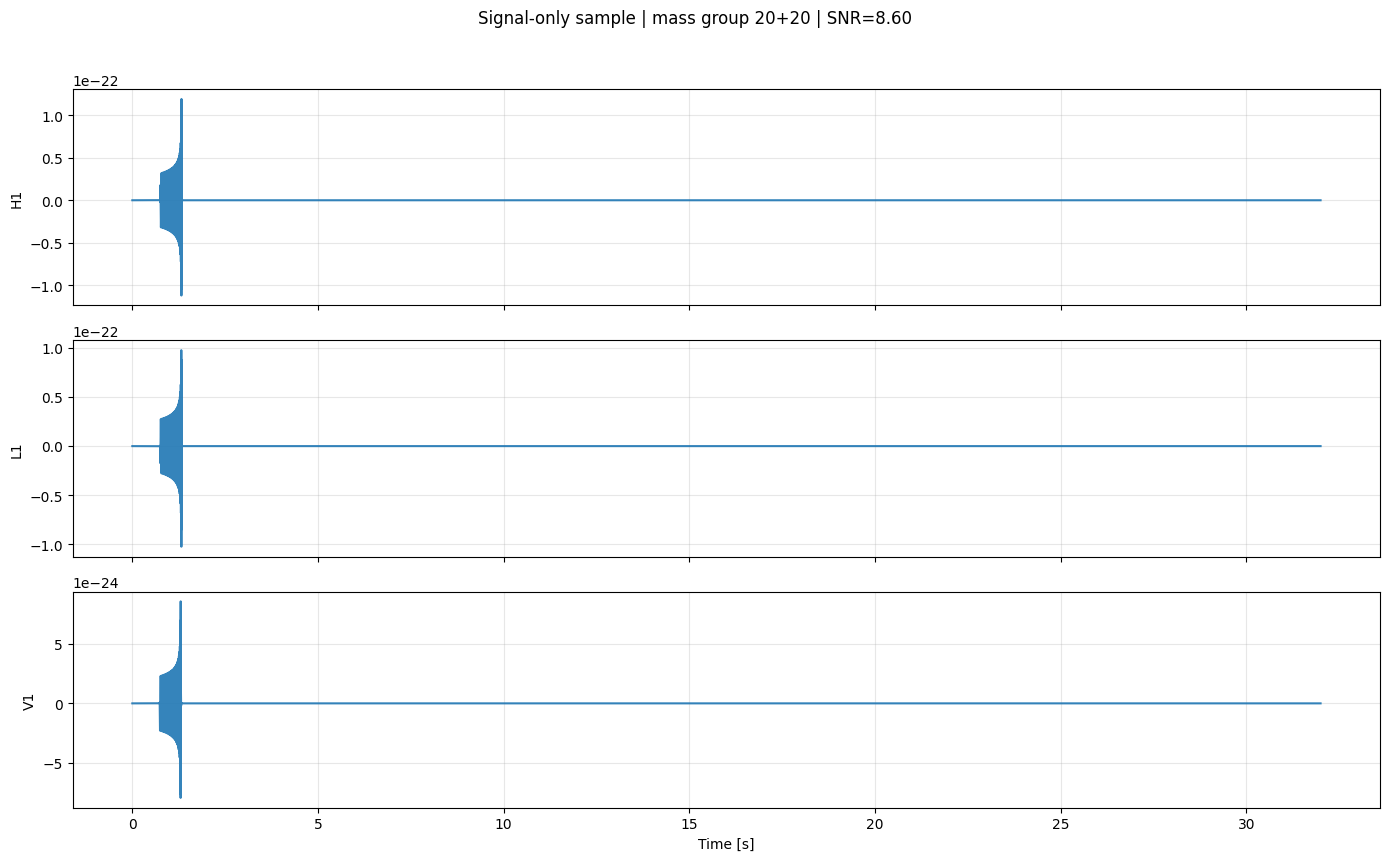

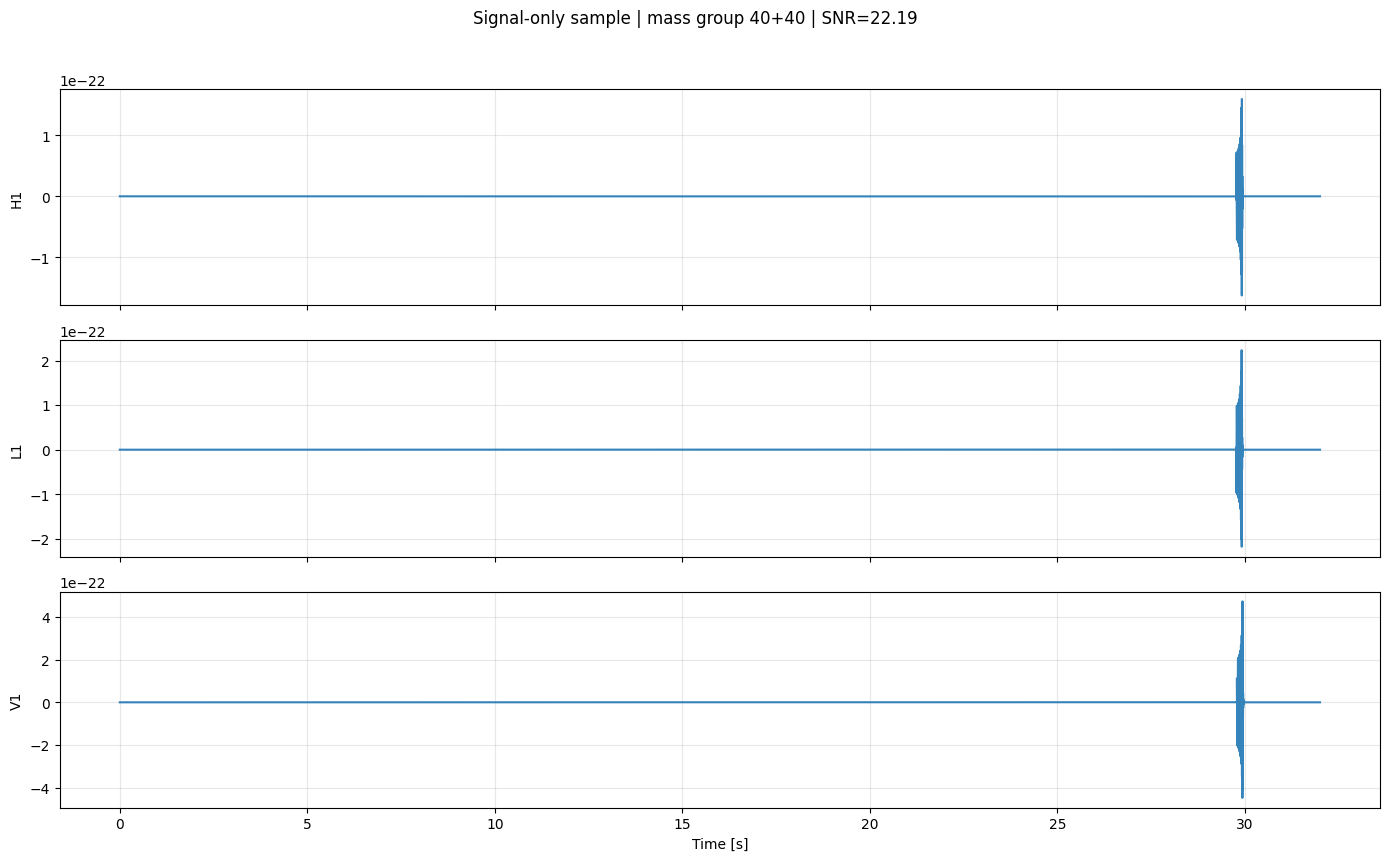

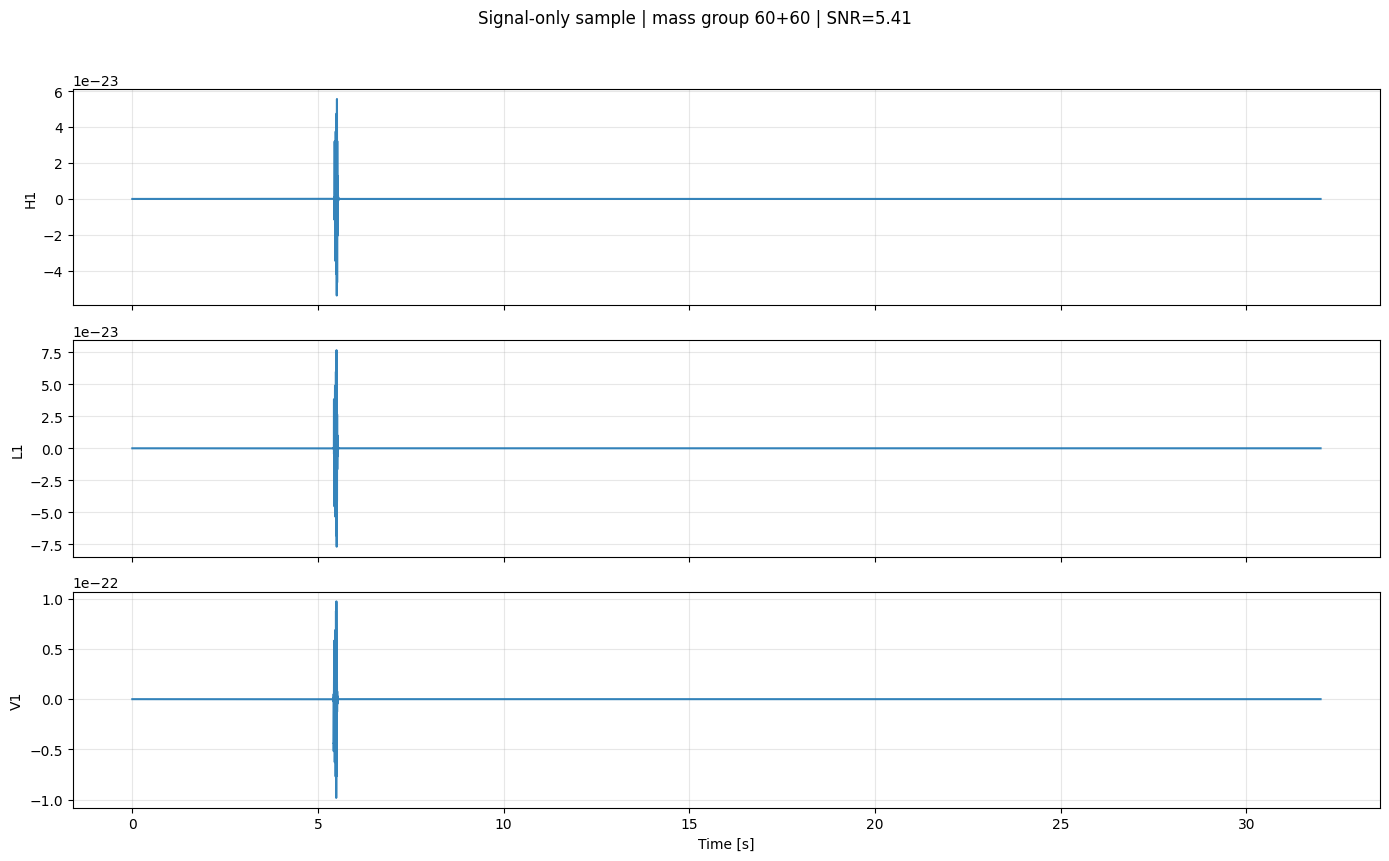

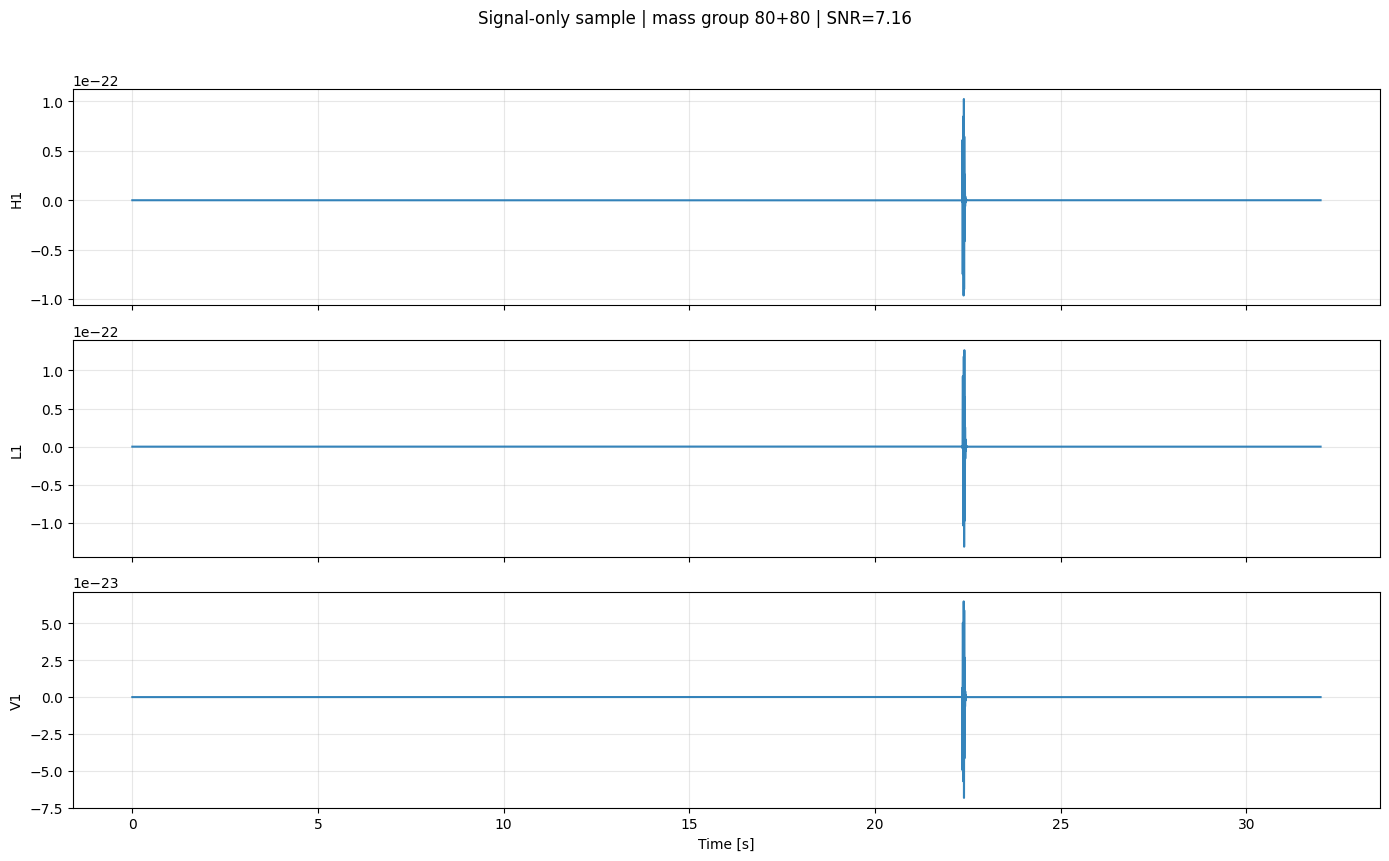

In [55]:
for mass in mass_groups:
    idx = int(signal_meta_df.query("mass_group == @mass").iloc[0]["index"])

    title = (
        f"Signal-only sample | mass group {mass:.0f}+{mass:.0f} | "
        f"SNR={signal_meta_df.loc[idx, 'network_snr']:.2f}"
    )

    plot_network_array(
        X_signal,
        sample_idx=idx,
        title=title,
        fs=config.sampling_frequency,
        detector_names=detector_names,
    )

In [56]:
def plot_network_peak_zoom(
    X,
    sample_idx,
    title="",
    fs=4096.0,
    detector_names=("H1", "L1", "V1"),
    window_seconds=4.0,
):
    x = X[sample_idx]
    network_abs = np.sqrt(np.sum(x**2, axis=0))
    peak_idx = int(np.argmax(network_abs))

    half = int(0.5 * window_seconds * fs)
    i0 = max(0, peak_idx - half)
    i1 = min(x.shape[-1], peak_idx + half)

    t = np.arange(x.shape[-1]) / fs

    fig, axes = plt.subplots(
        x.shape[0],
        1,
        figsize=(14, 2.8 * x.shape[0]),
        sharex=True,
    )

    if x.shape[0] == 1:
        axes = [axes]

    for det_idx in range(x.shape[0]):
        det = detector_names[det_idx]
        axes[det_idx].plot(t[i0:i1], x[det_idx, i0:i1], alpha=0.9)
        axes[det_idx].set_ylabel(det)
        axes[det_idx].grid(alpha=0.3)

    axes[-1].set_xlabel("Time [s]")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

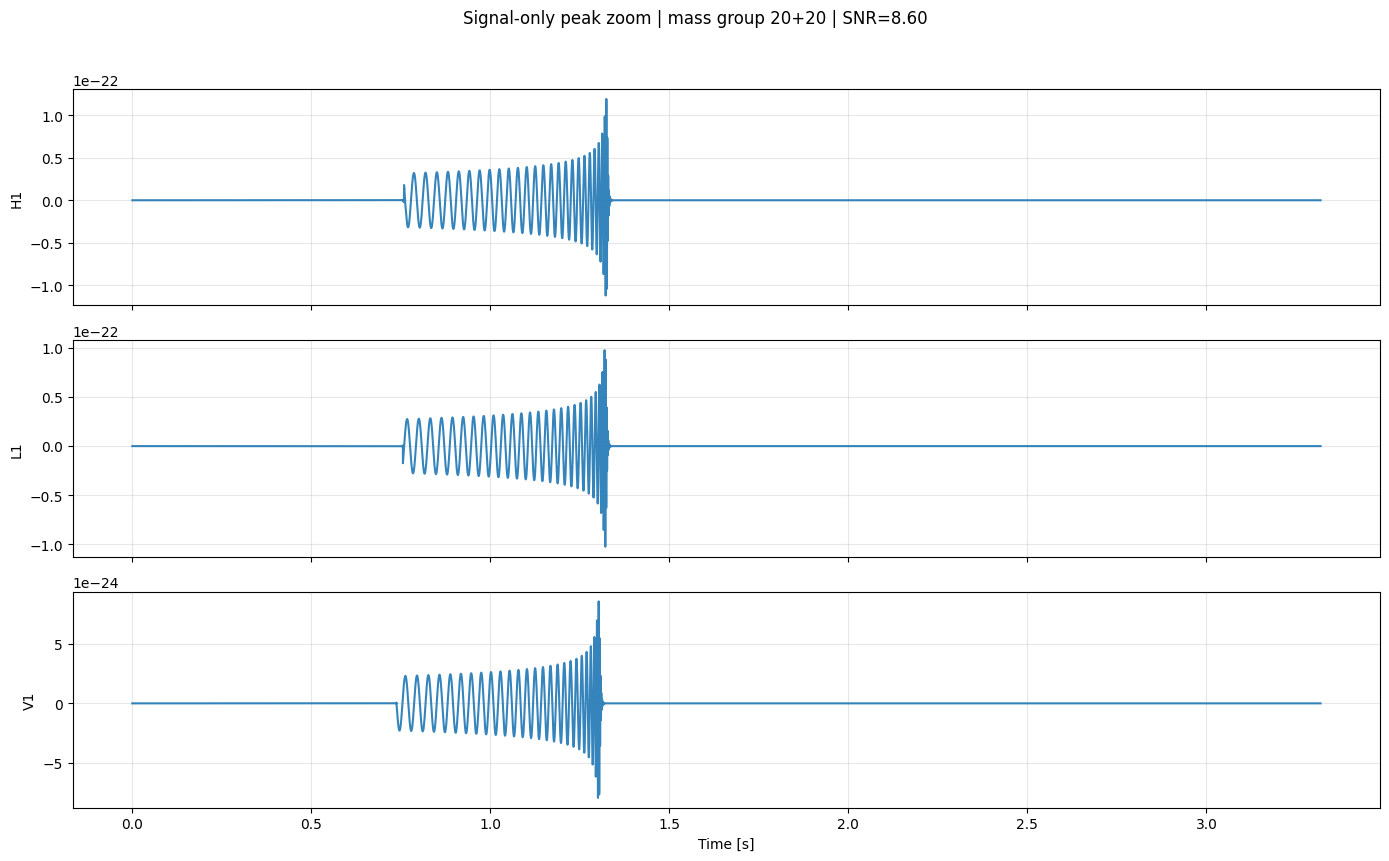

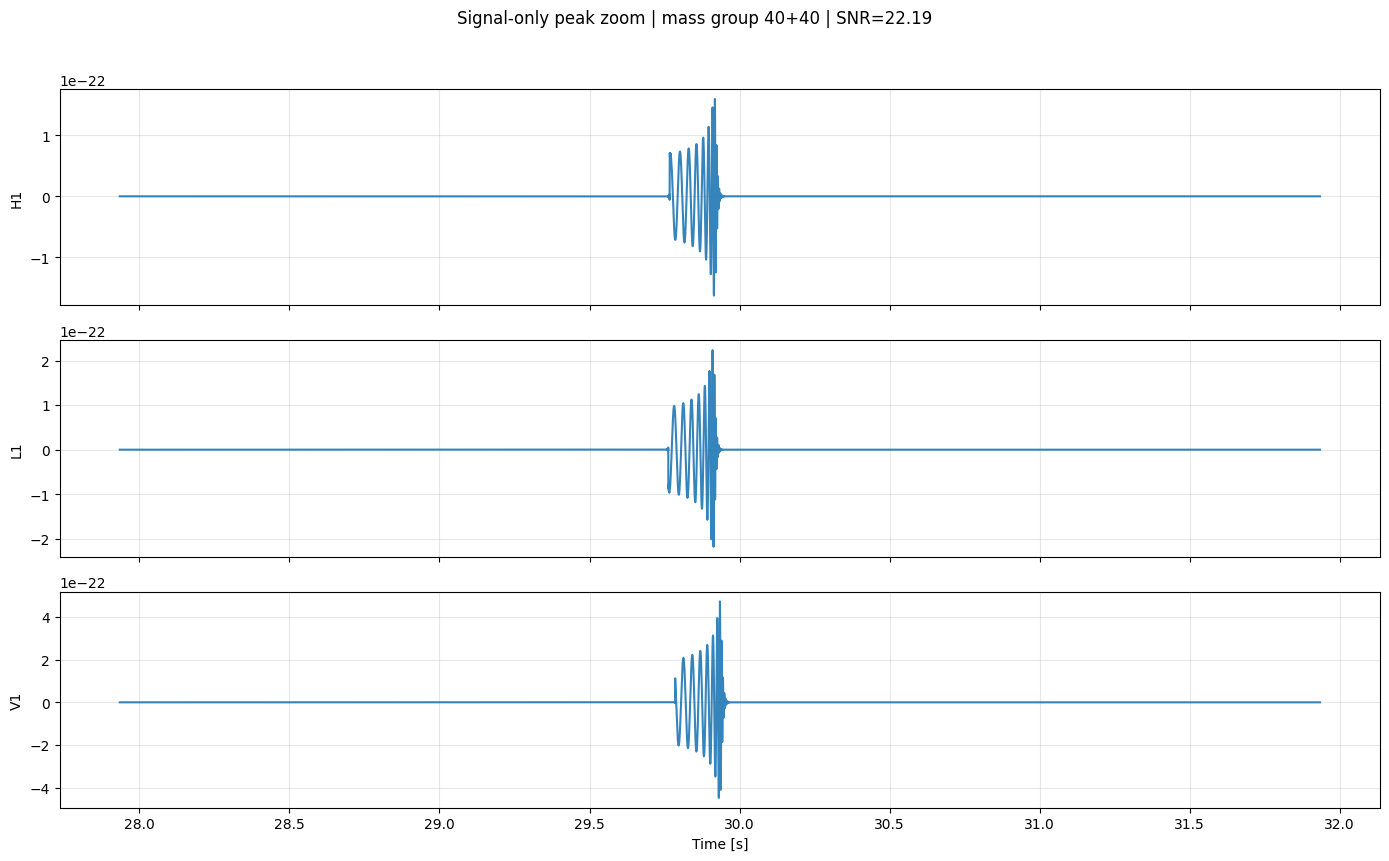

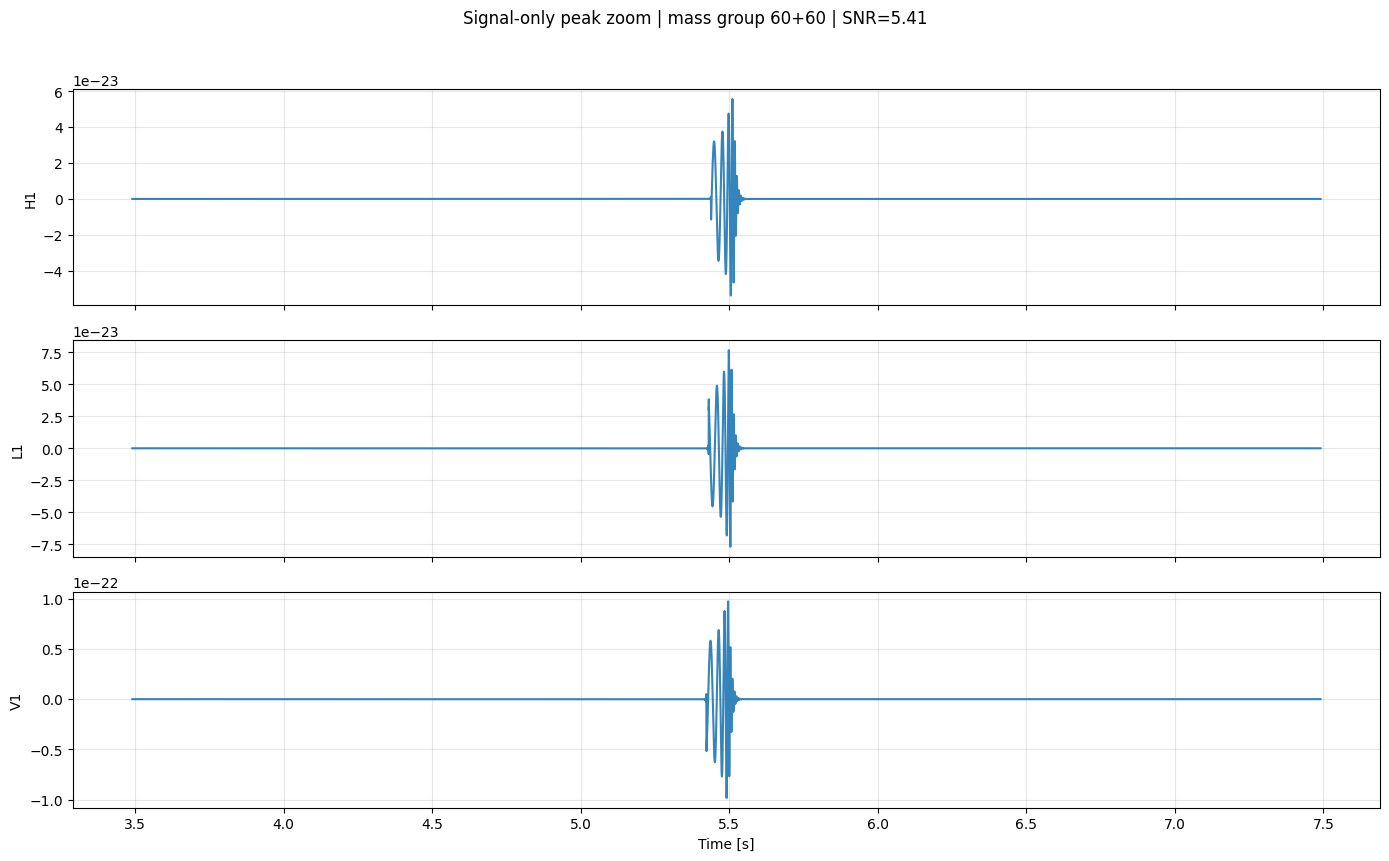

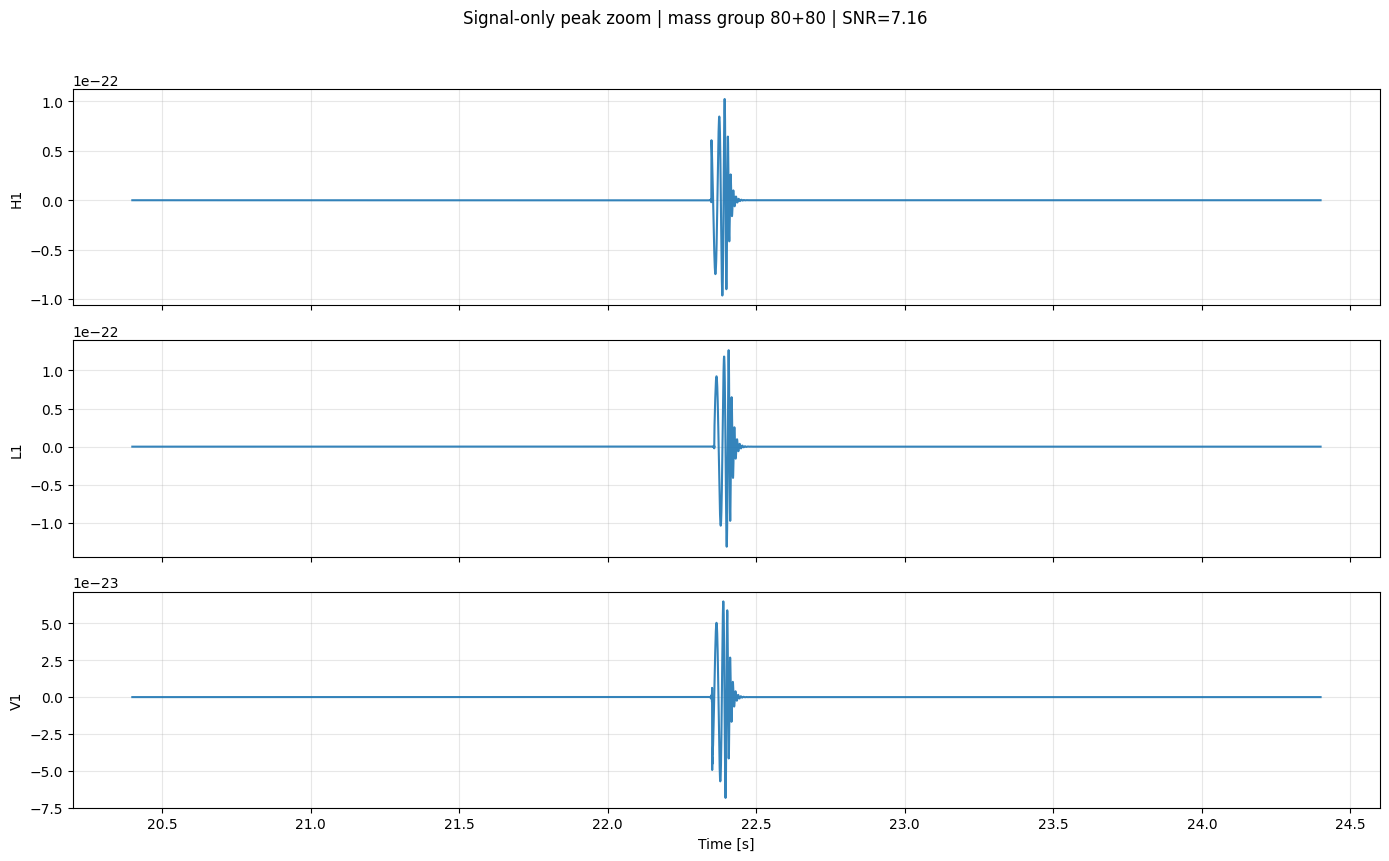

In [57]:
for mass in mass_groups:
    idx = int(signal_meta_df.query("mass_group == @mass").iloc[0]["index"])

    title = (
        f"Signal-only peak zoom | mass group {mass:.0f}+{mass:.0f} | "
        f"SNR={signal_meta_df.loc[idx, 'network_snr']:.2f}"
    )

    plot_network_peak_zoom(
        X_signal,
        sample_idx=idx,
        title=title,
        fs=config.sampling_frequency,
        detector_names=detector_names,
        window_seconds=4.0,
    )

## 6. Classification from signal-only arrays

Now we test whether a simple classifier can distinguish mass groups from signal-only arrays.

This is not meant to be a production model. It is a diagnostic test.

If this fails, the problem is upstream: generation, windowing, representation, or the chosen classes.

If this succeeds, then the physical mass information exists before noise and processing.

In [58]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


def evaluate_simple_classifier(X_feat, y, title="", test_size=0.25, seed=123):
    X_train, X_test, y_train, y_test = train_test_split(
        X_feat,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, C=1.0),
    )

    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    print("=" * 80)
    print(title)
    print("=" * 80)
    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("accuracy:", accuracy_score(y_test, pred))
    print()
    print(classification_report(y_test, pred))
    print()
    print("confusion matrix:")
    print(confusion_matrix(y_test, pred))

    return clf, pred, y_test

In [59]:
stride = 8

X_signal_down = X_signal[:, :, ::stride]
X_signal_flat = X_signal_down.reshape(X_signal_down.shape[0], -1)

print("X_signal_flat:", X_signal_flat.shape)

clf_signal, pred_signal, y_test_signal = evaluate_simple_classifier(
    X_feat=X_signal_flat,
    y=all_mass_labels,
    title=f"Signal-only classification using downsampled arrays, stride={stride}",
)

X_signal_flat: (80, 49152)
Signal-only classification using downsampled arrays, stride=8
X_train: (60, 49152)
X_test: (20, 49152)
accuracy: 0.2

              precision    recall  f1-score   support

        20.0       0.33      0.20      0.25         5
        40.0       0.33      0.20      0.25         5
        60.0       0.15      0.40      0.22         5
        80.0       0.00      0.00      0.00         5

    accuracy                           0.20        20
   macro avg       0.21      0.20      0.18        20
weighted avg       0.21      0.20      0.18        20


confusion matrix:
[[1 1 3 0]
 [0 1 4 0]
 [1 1 2 1]
 [1 0 4 0]]


In [60]:
def windowed_rms_features(X, n_windows=64):
    n, c, t = X.shape
    usable = (t // n_windows) * n_windows
    X_use = X[:, :, :usable]
    Xw = X_use.reshape(n, c, n_windows, usable // n_windows)
    rms = np.sqrt(np.mean(Xw**2, axis=-1))
    return rms.reshape(n, c * n_windows)


X_signal_winrms = windowed_rms_features(X_signal, n_windows=64)

print("X_signal_winrms:", X_signal_winrms.shape)

clf_signal_rms, pred_signal_rms, y_test_signal_rms = evaluate_simple_classifier(
    X_feat=X_signal_winrms,
    y=all_mass_labels,
    title="Signal-only classification using windowed RMS features",
)

X_signal_winrms: (80, 192)
Signal-only classification using windowed RMS features
X_train: (60, 192)
X_test: (20, 192)
accuracy: 0.15

              precision    recall  f1-score   support

        20.0       0.00      0.00      0.00         5
        40.0       0.17      0.40      0.24         5
        60.0       0.50      0.20      0.29         5
        80.0       0.00      0.00      0.00         5

    accuracy                           0.15        20
   macro avg       0.17      0.15      0.13        20
weighted avg       0.17      0.15      0.13        20


confusion matrix:
[[0 5 0 0]
 [0 2 1 2]
 [1 1 1 2]
 [1 4 0 0]]


## 7. First decision point

Interpretation:

- If signal-only classification works well:
  - waveform generation, projection and windowing are probably fine;
  - the issue appears after adding noise, preprocessing, or using 32 s noisy segments.

- If signal-only classification fails:
  - inspect waveform/windowing more deeply;
  - check whether crops are correctly aligned;
  - check whether the mass groups are physically represented as expected.

## Experimento A — fixed extrinsics + fixed distance + aligned placement

In [61]:
def make_fixed_params(mass, distance=1000.0):
    return CBCParameters(
        mass_1=float(mass),
        mass_2=float(mass),
        distance=float(distance),
        inclination=0.7,
        ra=1.0,
        dec=0.5,
        spin_1z=0.0,
        spin_2z=0.0,
        polarization_angle=0.0,
    )

In [62]:
fixed_params = []
fixed_labels = []

for mass in [20.0, 40.0, 60.0, 80.0]:
    fixed_params.append(make_fixed_params(mass, distance=1000.0))
    fixed_labels.append(mass)

fixed_labels = np.asarray(fixed_labels)

In [63]:
X_fixed, fixed_meta_df = build_signal_only_collection(
    builder=builder,
    params_list=fixed_params,
    mass_labels=fixed_labels,
    geocentric_coalescence_time=1126259462.0,
    placement_policy="end_aligned",
)

print("X_fixed:", X_fixed.shape)
fixed_meta_df

Built 4/4 signal-only samples
X_fixed: (4, 3, 131072)


,index,mass_group,mass_1,mass_2,distance,chirp_mass,total_mass,chi_eff,network_snr,snr_H1,snr_L1,snr_V1,segment_start_time,segment_end_time,margin_before_signal,margin_after_signal,signal_network_duration,is_truncated,used_window_duration,full_network_duration
0,0,20.0,20.0,20.0,1000.0,17.411011,40.0,0.0,27.937265,17.131591,20.284257,8.691852,1.126259e+09,1.126259e+09,31.326904,0.0,0.673096,False,0.673096,0.673096
1,1,40.0,40.0,40.0,1000.0,34.822023,80.0,0.0,47.519899,29.155022,34.513672,14.728611,1.126259e+09,1.126259e+09,31.666260,0.0,0.333740,False,0.333740,0.333740
2,2,60.0,60.0,60.0,1000.0,52.233034,120.0,0.0,65.410024,40.112919,47.494429,20.339720,1.126259e+09,1.126259e+09,31.667480,0.0,0.332520,False,0.332520,0.332520
3,3,80.0,80.0,80.0,1000.0,69.644045,160.0,0.0,84.442870,51.978002,61.536859,25.339704,1.126259e+09,1.126259e+09,31.617188,0.0,0.382812,False,0.382812,0.382812


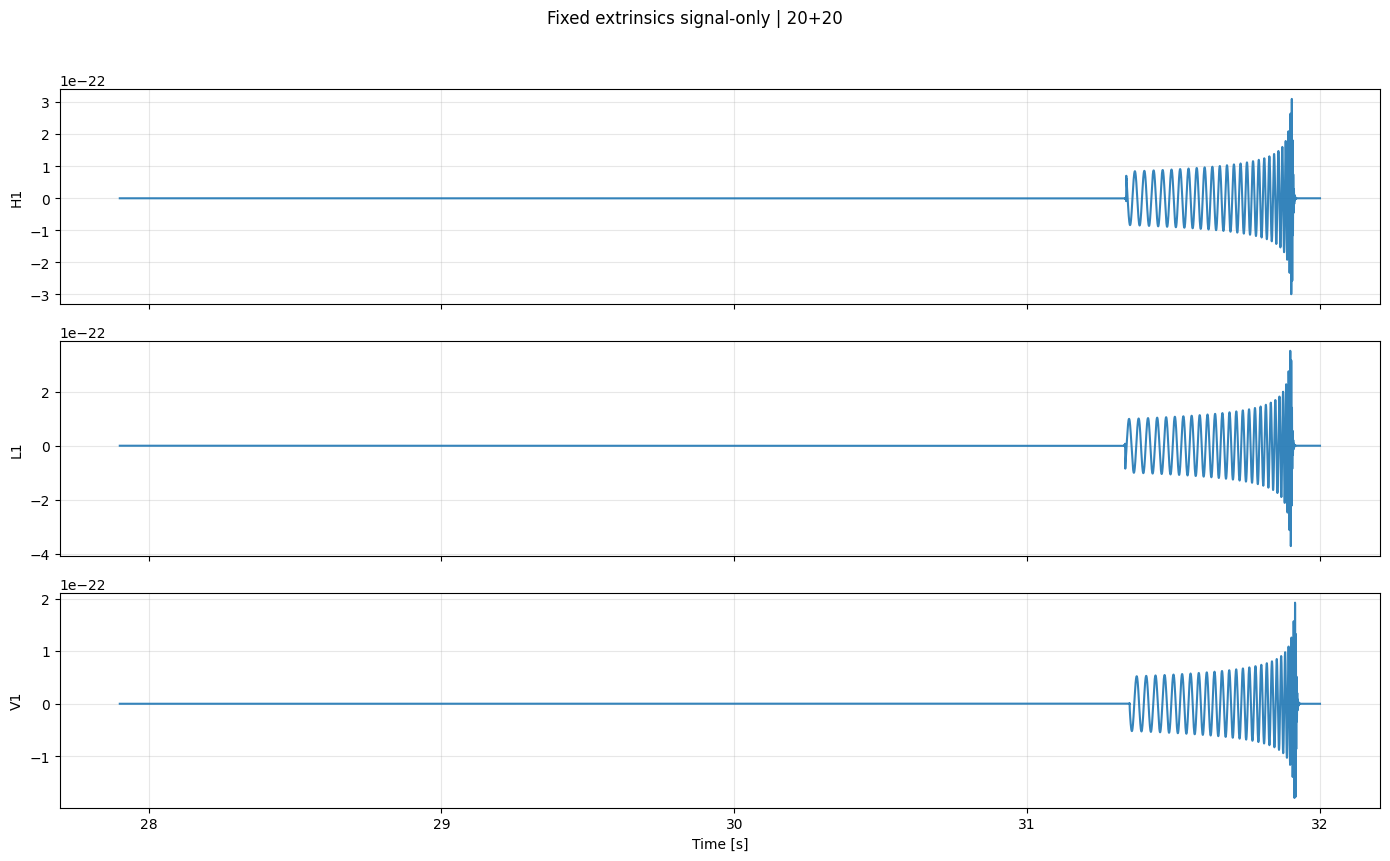

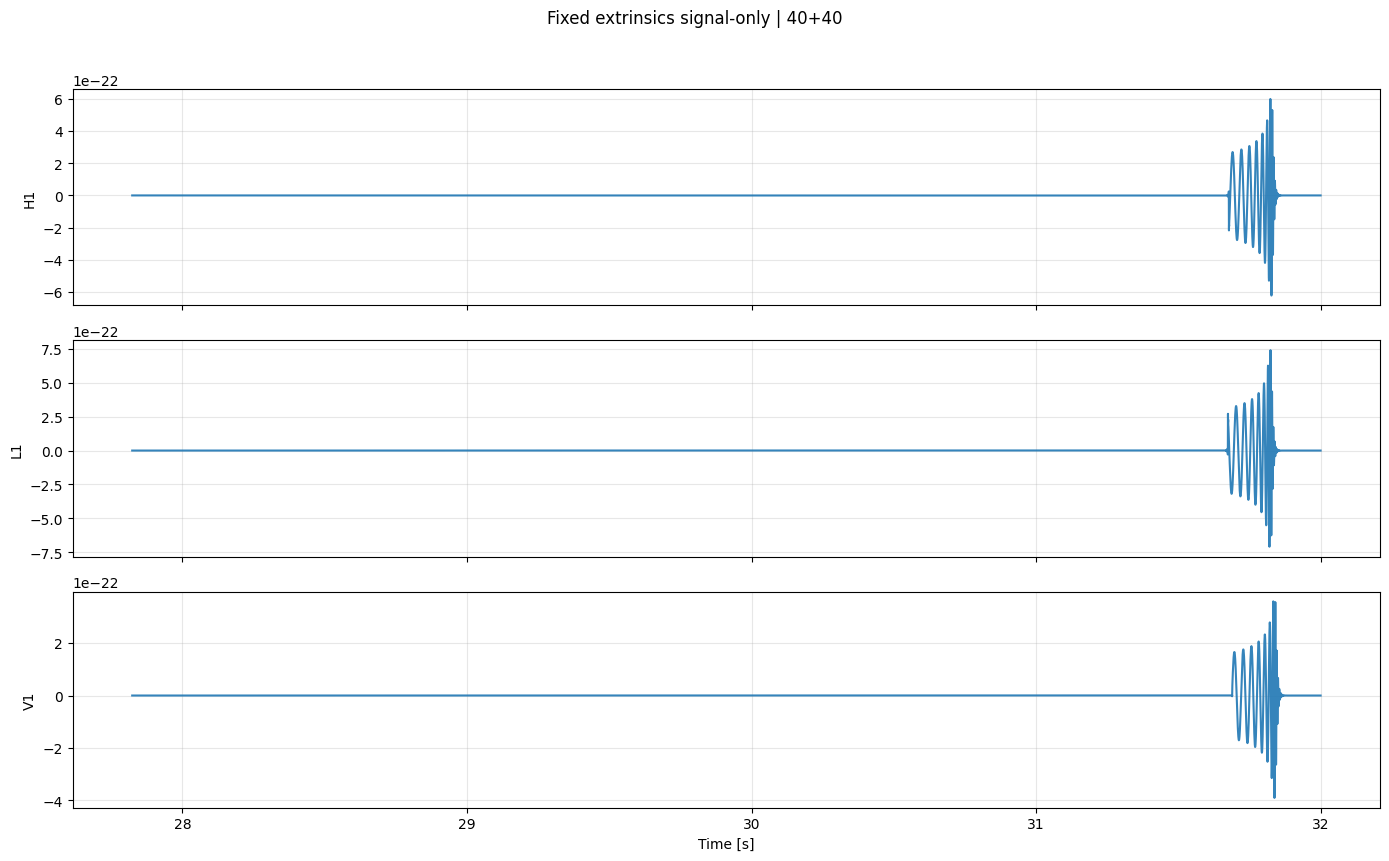

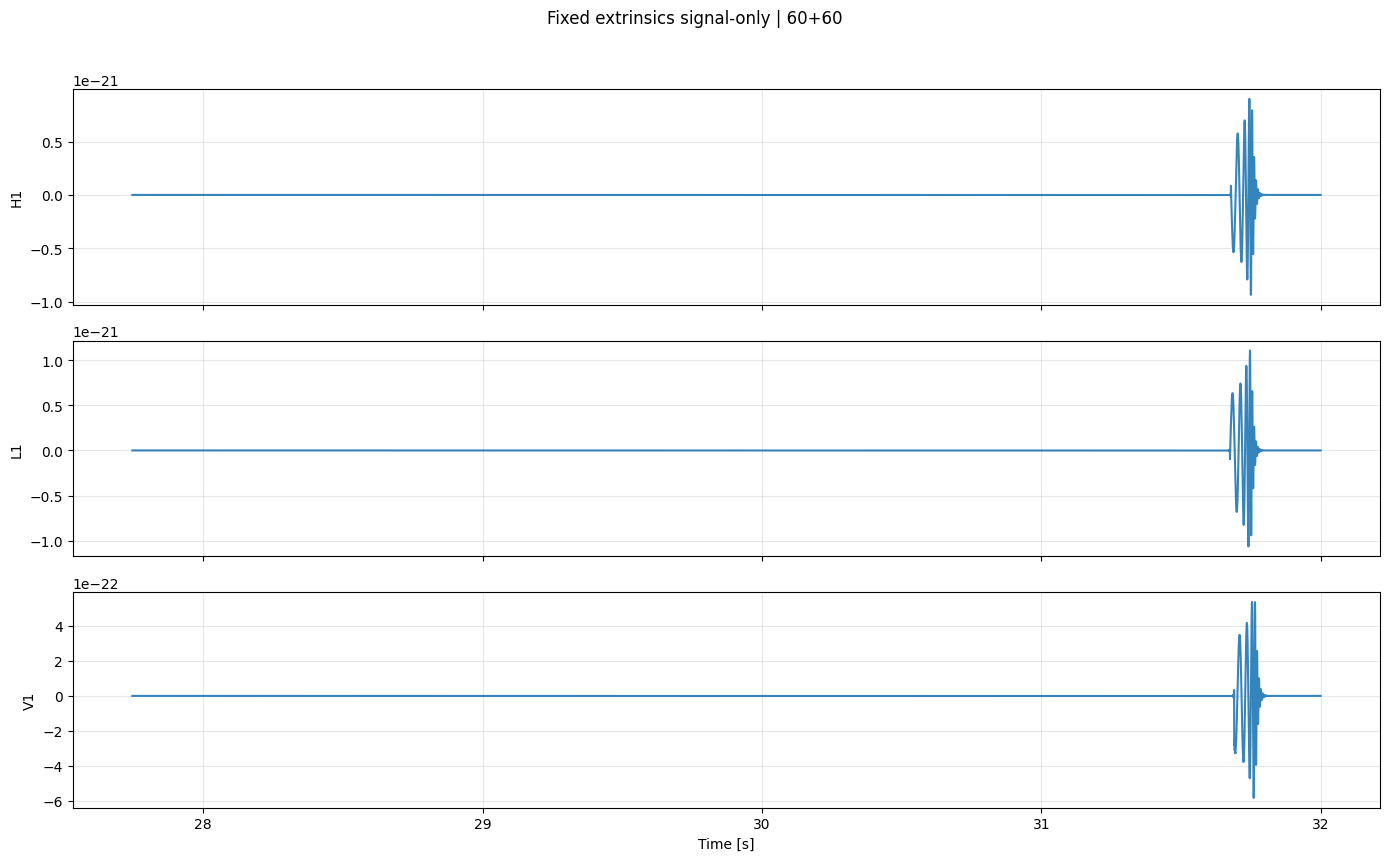

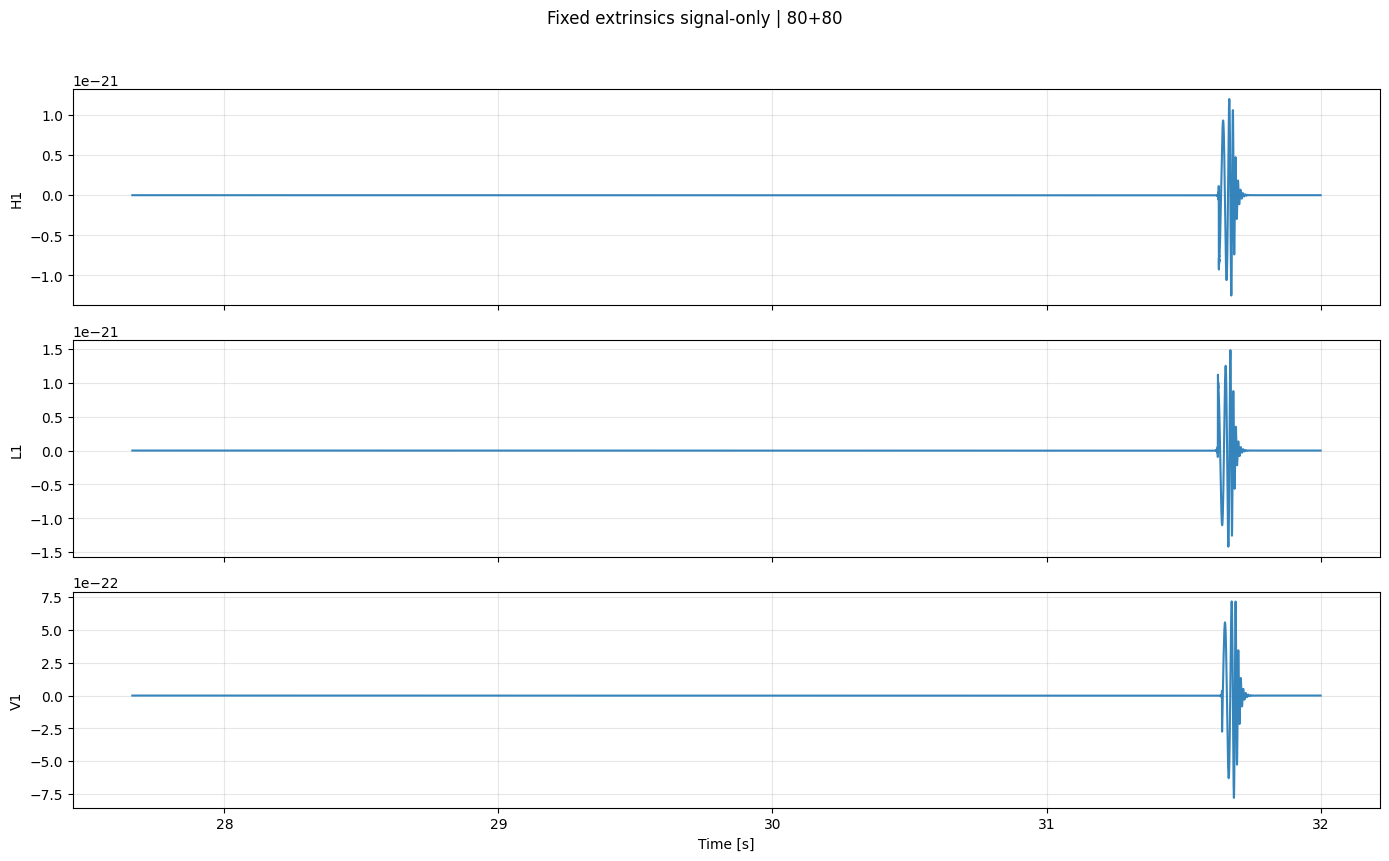

In [64]:
for i, mass in enumerate(fixed_labels):
    plot_network_peak_zoom(
        X_fixed,
        sample_idx=i,
        title=f"Fixed extrinsics signal-only | {mass:.0f}+{mass:.0f}",
        fs=config.sampling_frequency,
        detector_names=detector_names,
        window_seconds=8.0,
    )

## Experimento B — signal-only con extrínsecos variables, pero normalizando amplitud y alineando por peak

In [80]:
def crop_around_network_peak_array(X, crop_seconds=8.0, fs=4096.0):
    """
    Crop each sample around the maximum network amplitude.

    Important:
    We cast to float64 before squaring because physical strain amplitudes
    can be around 1e-23, and squaring float32 values can underflow.
    """
    n, c, t = X.shape
    crop_len = int(round(crop_seconds * fs))

    if crop_len > t:
        raise ValueError("crop_len cannot be larger than signal length.")

    crops = np.zeros((n, c, crop_len), dtype=X.dtype)

    X64 = X.astype(np.float64)
    network_abs = np.sqrt(np.sum(X64**2, axis=1))  # shape (n_samples, n_time)
    peak_indices = np.argmax(network_abs, axis=1)

    for i in range(n):
        center = int(peak_indices[i])

        start = center - crop_len // 2
        end = start + crop_len

        if start < 0:
            start = 0
            end = crop_len

        if end > t:
            end = t
            start = t - crop_len

        crops[i] = X[i, :, start:end]

    return crops, peak_indices


def normalize_per_sample_network(X, eps=1e-300):
    """
    Normalize each sample by its own network RMS.

    Important:
    We cast to float64 before squaring because physical strain amplitudes
    can be around 1e-22, and squaring float32 values can underflow.
    """
    X64 = X.astype(np.float64)

    scale = np.sqrt(np.mean(X64**2, axis=(1, 2), keepdims=True))

    if np.any(scale <= 0):
        bad = np.where(scale.reshape(-1) <= 0)[0]
        raise ValueError(f"Found samples with zero RMS: {bad}")

    X_norm = X64 / np.maximum(scale, eps)

    return X_norm.astype(np.float32), scale.reshape(-1)

In [81]:
X_signal_crop, signal_peak_indices = crop_around_network_peak_array(
    X_signal,
    crop_seconds=8.0,
    fs=config.sampling_frequency,
)

X_signal_crop_norm, crop_scales = normalize_per_sample_network(X_signal_crop)

rms_check = np.sqrt(
    np.mean(
        X_signal_crop_norm.astype(np.float64)**2,
        axis=(1, 2),
    )
)

print("X_signal_crop_norm:", X_signal_crop_norm.shape)
print("mean/std:", X_signal_crop_norm.mean(), X_signal_crop_norm.std())
print("scale min/max:", crop_scales.min(), crop_scales.max())
print("per-sample RMS:", rms_check[:10])
print("RMS min/max:", rms_check.min(), rms_check.max())

X_signal_crop_norm: (80, 3, 32768)
mean/std: 0.00021589185 0.99999994
scale min/max: 1.378129358428637e-24 1.3334948615333444e-22
per-sample RMS: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
RMS min/max: 0.9999999978345768 1.000000002935153


In [86]:
stride = 8

X_feat = X_signal_crop_norm[:, :, ::stride]
X_feat = X_feat.reshape(X_feat.shape[0], -1)

clf_signal_crop_norm, pred_signal_crop_norm, y_test_signal_crop_norm = evaluate_simple_classifier(
    X_feat=X_feat,
    y=all_mass_labels,
    title="Signal-only classification: peak crop + per-sample normalization",
)

Signal-only classification: peak crop + per-sample normalization
X_train: (60, 12288)
X_test: (20, 12288)
accuracy: 0.4

              precision    recall  f1-score   support

        20.0       1.00      0.20      0.33         5
        40.0       0.67      0.40      0.50         5
        60.0       0.30      0.60      0.40         5
        80.0       0.33      0.40      0.36         5

    accuracy                           0.40        20
   macro avg       0.57      0.40      0.40        20
weighted avg       0.57      0.40      0.40        20


confusion matrix:
[[1 0 2 2]
 [0 2 3 0]
 [0 0 3 2]
 [0 1 2 2]]


## Experimento C — usar features de duración de señal desde metadata

In [ ]:
duration_features = signal_meta_df[
    [
        "signal_network_duration",
        "used_window_duration",
        "full_network_duration",
    ]
].to_numpy()

clf_duration, pred_duration, y_test_duration = evaluate_simple_classifier(
    X_feat=duration_features,
    y=all_mass_labels,
    title="Mass classification using signal duration metadata",
)

In [69]:
signal_meta_df.groupby("mass_group")[
    ["signal_network_duration", "used_window_duration", "full_network_duration"]
].describe()

signal_network_duration                                          \
                             count      mean       std       min       25%   
mass_group                                                                   
20.0                          20.0  0.676685  0.005912  0.662842  0.672974   
40.0                          20.0  0.336853  0.007328  0.323486  0.329407   
60.0                          20.0  0.333679  0.007902  0.322266  0.326599   
80.0                          20.0  0.384924  0.005629  0.377197  0.380615   

                                         used_window_duration            ...  \
                 50%       75%       max                count      mean  ...   
mass_group                                                               ...   
20.0        0.678345  0.682007  0.684326                 20.0  0.676685  ...   
40.0        0.340454  0.342041  0.345215                 20.0  0.336853  ...   
60.0        0.335205  0.339844  0.345215                 20.0  0.333679  ...   
80.0        0.385254  0.388184  0.394531                 20.0  0.384924  ...   

                               full_network_duration                      \
                 75%       max                 count      mean       std   
mass_group                                                                 
20.0        0.682007  0.684326                  20.0  0.676685  0.005912   
40.0        0.342041  0.345215                  20.0  0.336853  0.007328   
60.0        0.339844  0.345215                  20.0  0.333679  0.007902   
80.0        0.388184  0.394531                  20.0  0.384924  0.005629   

                                                              
                 min       25%       50%       75%       max  
mass_group                                                    
20.0        0.662842  0.672974  0.678345  0.682007  0.684326  
40.0        0.323486  0.329407  0.340454  0.342041  0.345215  
60.0        0.322266  0.326599  0.335205  0.339844  0.345215  
80.0        0.377197  0.380615  0.385254  0.388184  0.394531  

[4 rows x 24 columns]

In [70]:
waveform_rows = []

for mass in [20.0, 40.0, 60.0, 80.0]:
    p = make_fixed_params(mass, distance=1000.0)
    wf = builder.waveform_generator.generate(p)

    waveform_rows.append({
        "mass_group": mass,
        "waveform_duration": wf.metadata.duration,
        "n_samples": wf.metadata.n_samples,
        "start_time": wf.metadata.start_time,
        "end_time": wf.metadata.end_time,
    })

waveform_df = pd.DataFrame(waveform_rows)
waveform_df

,mass_group,waveform_duration,n_samples,start_time,end_time
0,20.0,0.642090,2630,-0.565628,0.076462
1,40.0,0.302734,1240,-0.150124,0.152611
2,60.0,0.301514,1235,-0.072460,0.229054
3,80.0,0.351807,1441,-0.046829,0.304977


## Fixed parameters

In [87]:
def make_fixed_params(mass, distance=1000.0):
    return CBCParameters(
        mass_1=float(mass),
        mass_2=float(mass),
        distance=float(distance),
        inclination=0.7,
        ra=1.0,
        dec=0.5,
        spin_1z=0.0,
        spin_2z=0.0,
        polarization_angle=0.0,
    )


fixed_params = []
fixed_labels = []

for mass in [20.0, 40.0, 60.0, 80.0]:
    fixed_params.append(make_fixed_params(mass, distance=1000.0))
    fixed_labels.append(mass)

fixed_labels = np.asarray(fixed_labels)

In [88]:
X_fixed, fixed_meta_df = build_signal_only_collection(
    builder=builder,
    params_list=fixed_params,
    mass_labels=fixed_labels,
    geocentric_coalescence_time=1126259462.0,
    placement_policy="end_aligned",
)

print("X_fixed:", X_fixed.shape)
fixed_meta_df

Built 4/4 signal-only samples
X_fixed: (4, 3, 131072)


,index,mass_group,mass_1,mass_2,distance,chirp_mass,total_mass,chi_eff,network_snr,snr_H1,snr_L1,snr_V1,segment_start_time,segment_end_time,margin_before_signal,margin_after_signal,signal_network_duration,is_truncated,used_window_duration,full_network_duration
0,0,20.0,20.0,20.0,1000.0,17.411011,40.0,0.0,27.937265,17.131591,20.284257,8.691852,1.126259e+09,1.126259e+09,31.326904,0.0,0.673096,False,0.673096,0.673096
1,1,40.0,40.0,40.0,1000.0,34.822023,80.0,0.0,47.519899,29.155022,34.513672,14.728611,1.126259e+09,1.126259e+09,31.666260,0.0,0.333740,False,0.333740,0.333740
2,2,60.0,60.0,60.0,1000.0,52.233034,120.0,0.0,65.410024,40.112919,47.494429,20.339720,1.126259e+09,1.126259e+09,31.667480,0.0,0.332520,False,0.332520,0.332520
3,3,80.0,80.0,80.0,1000.0,69.644045,160.0,0.0,84.442870,51.978002,61.536859,25.339704,1.126259e+09,1.126259e+09,31.617188,0.0,0.382812,False,0.382812,0.382812


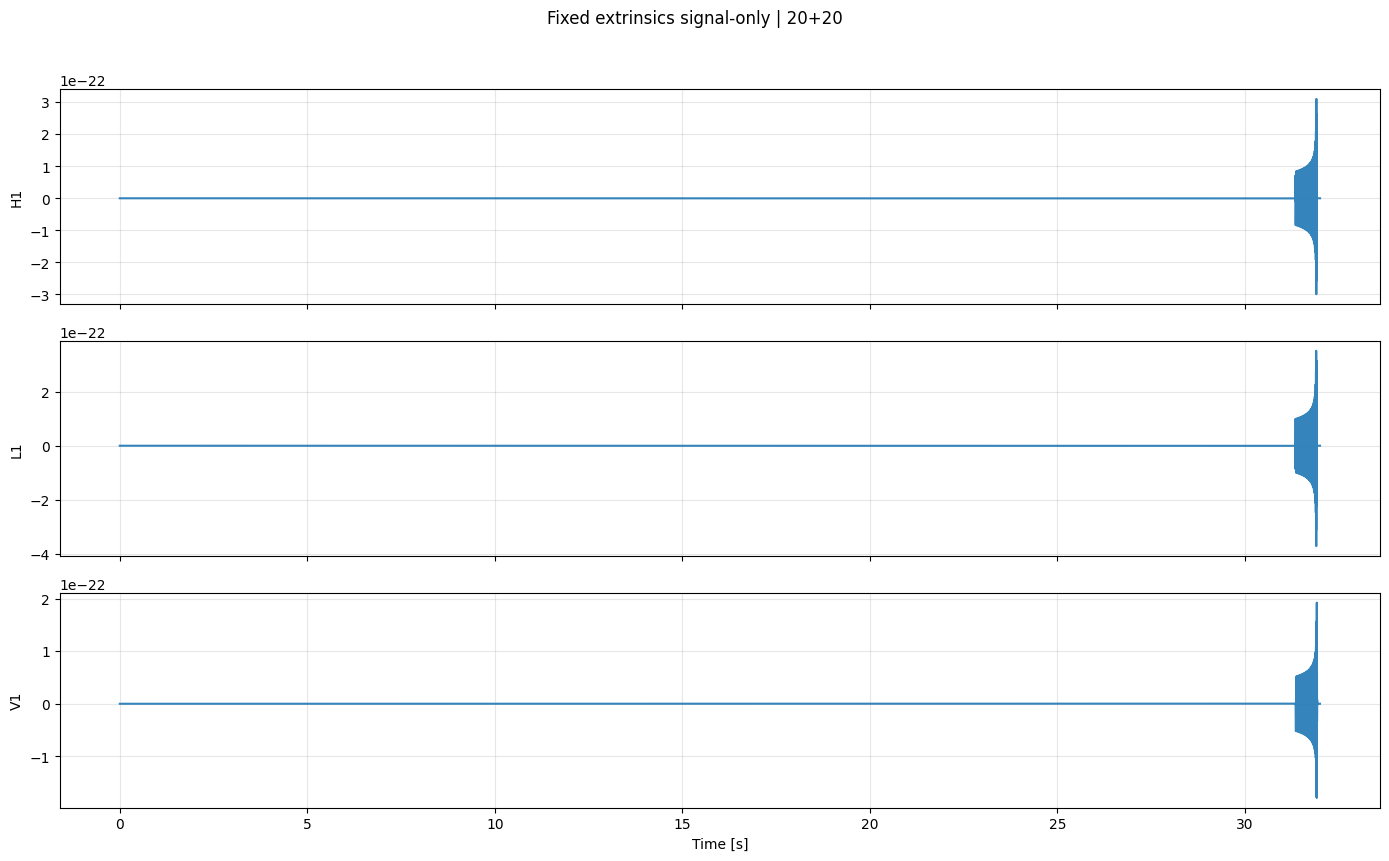

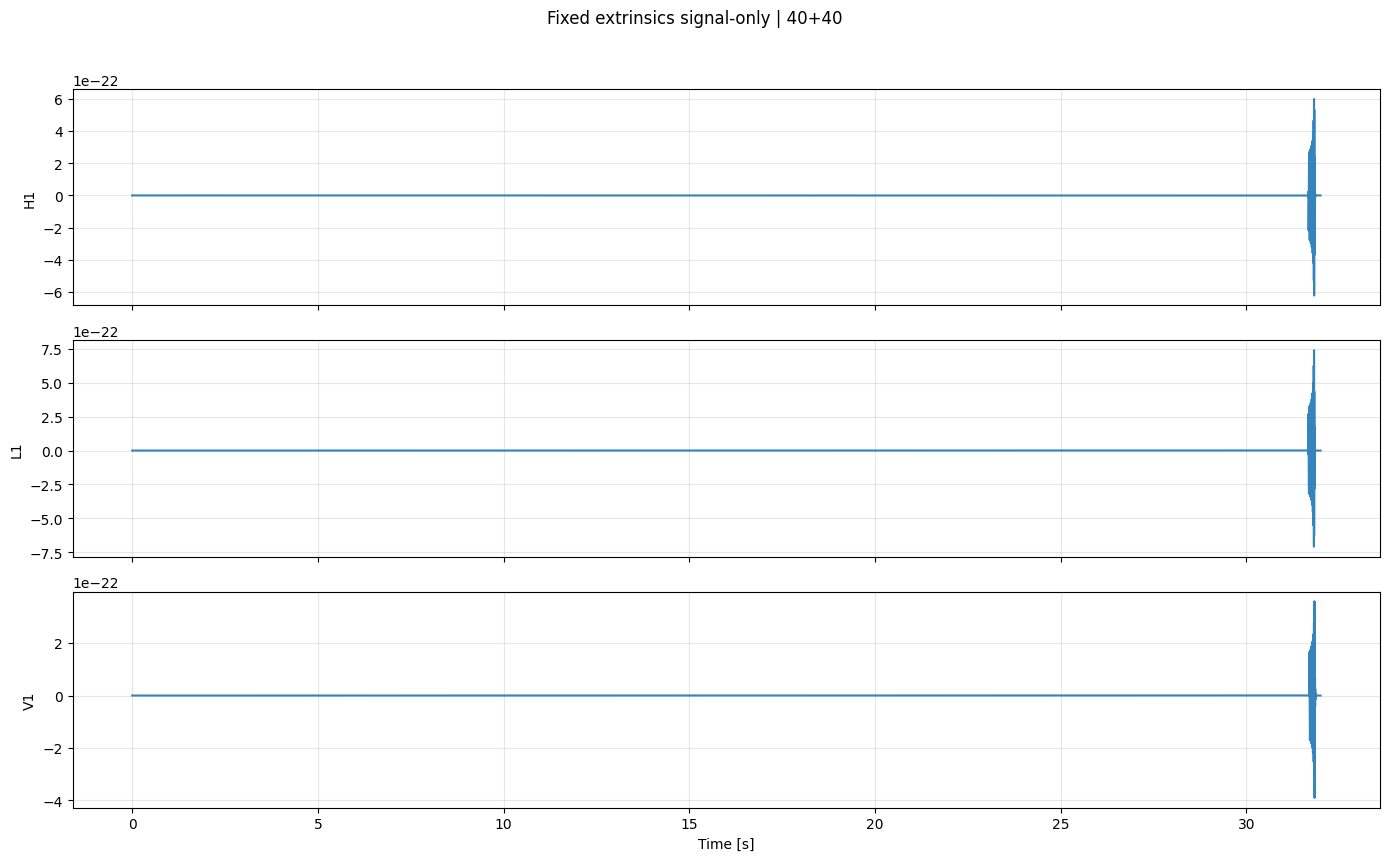

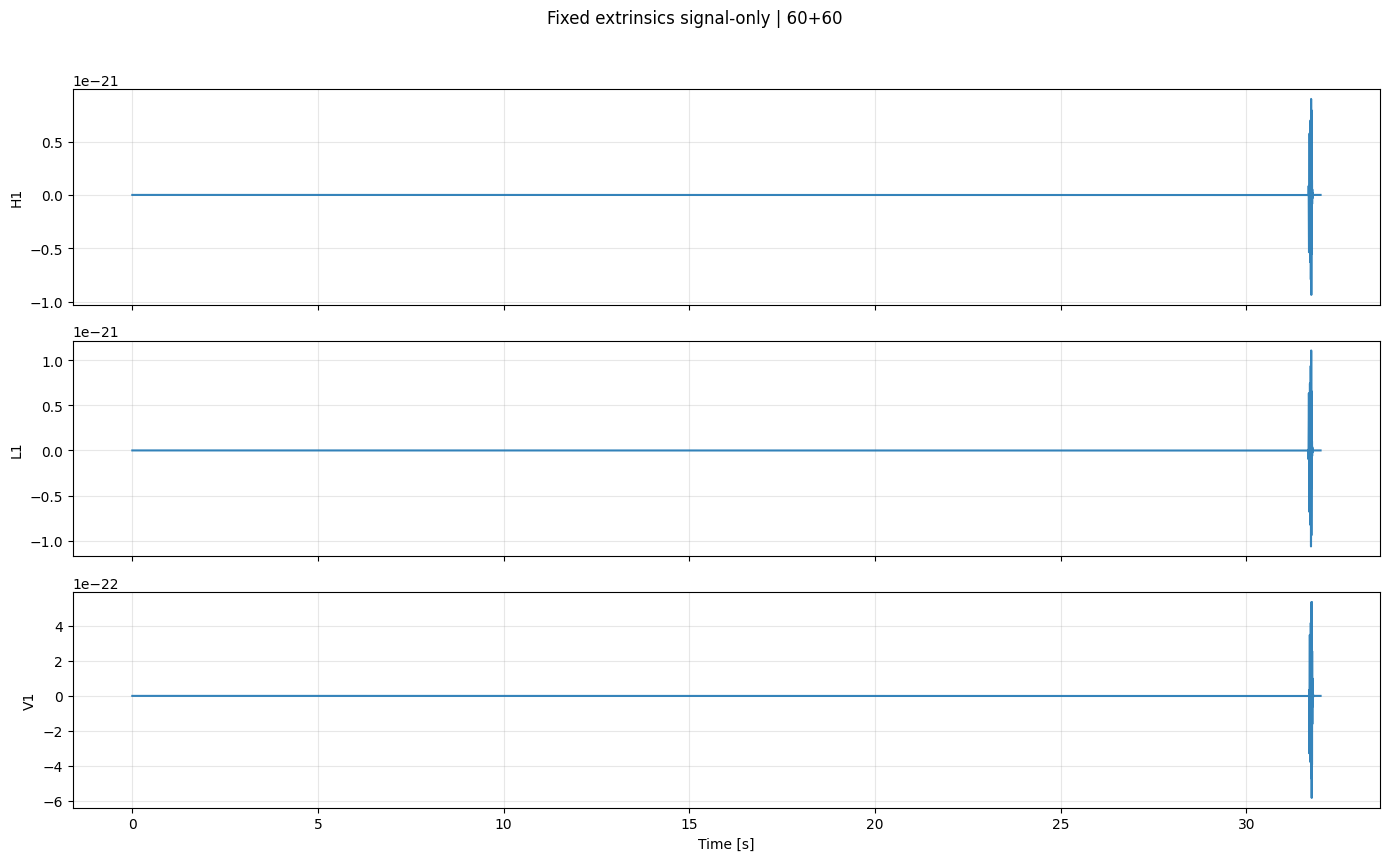

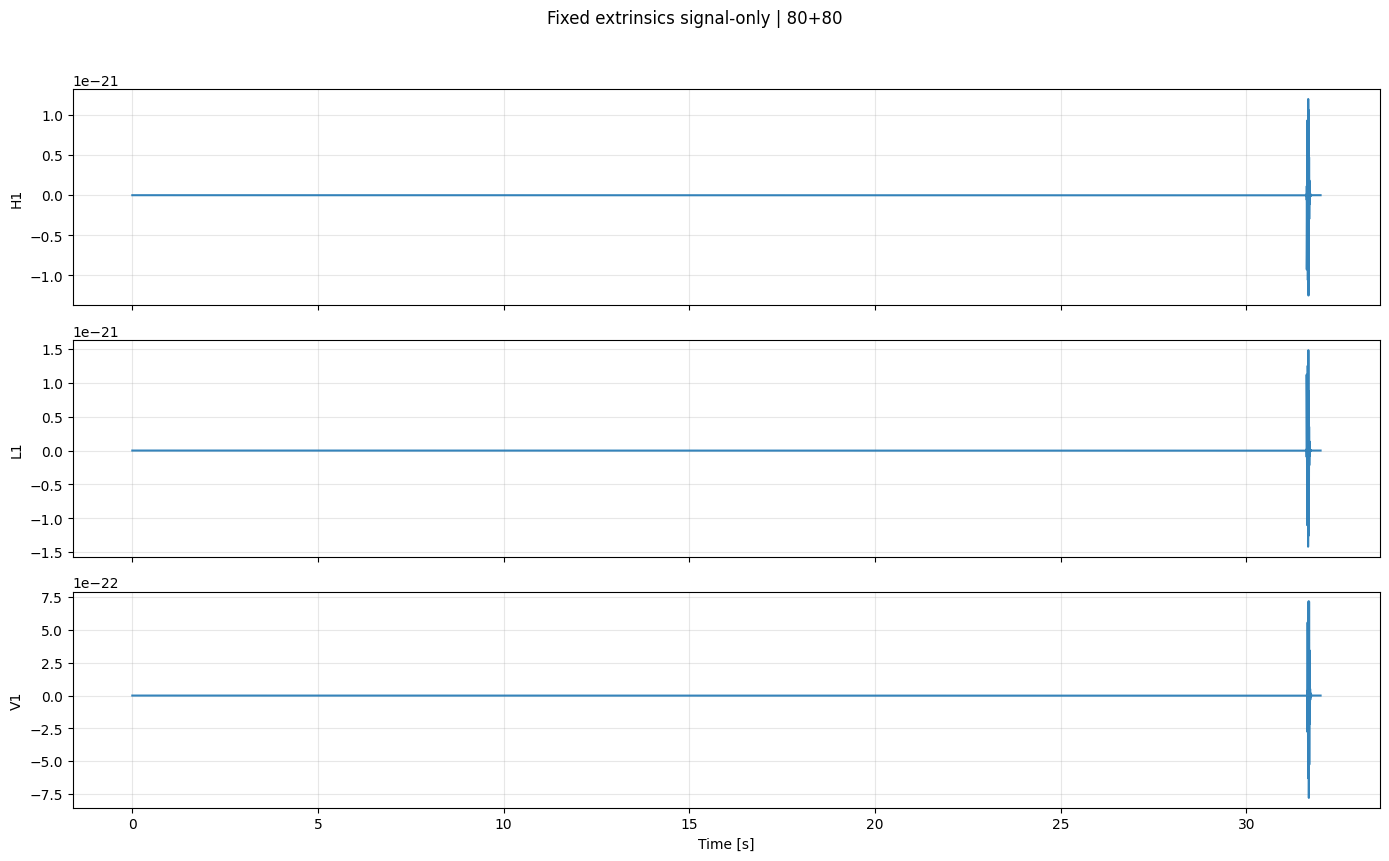

In [89]:
for i, mass in enumerate(fixed_labels):
    plot_network_array(
        X_fixed,
        sample_idx=i,
        title=f"Fixed extrinsics signal-only | {mass:.0f}+{mass:.0f}",
        fs=config.sampling_frequency,
        detector_names=detector_names,
    )

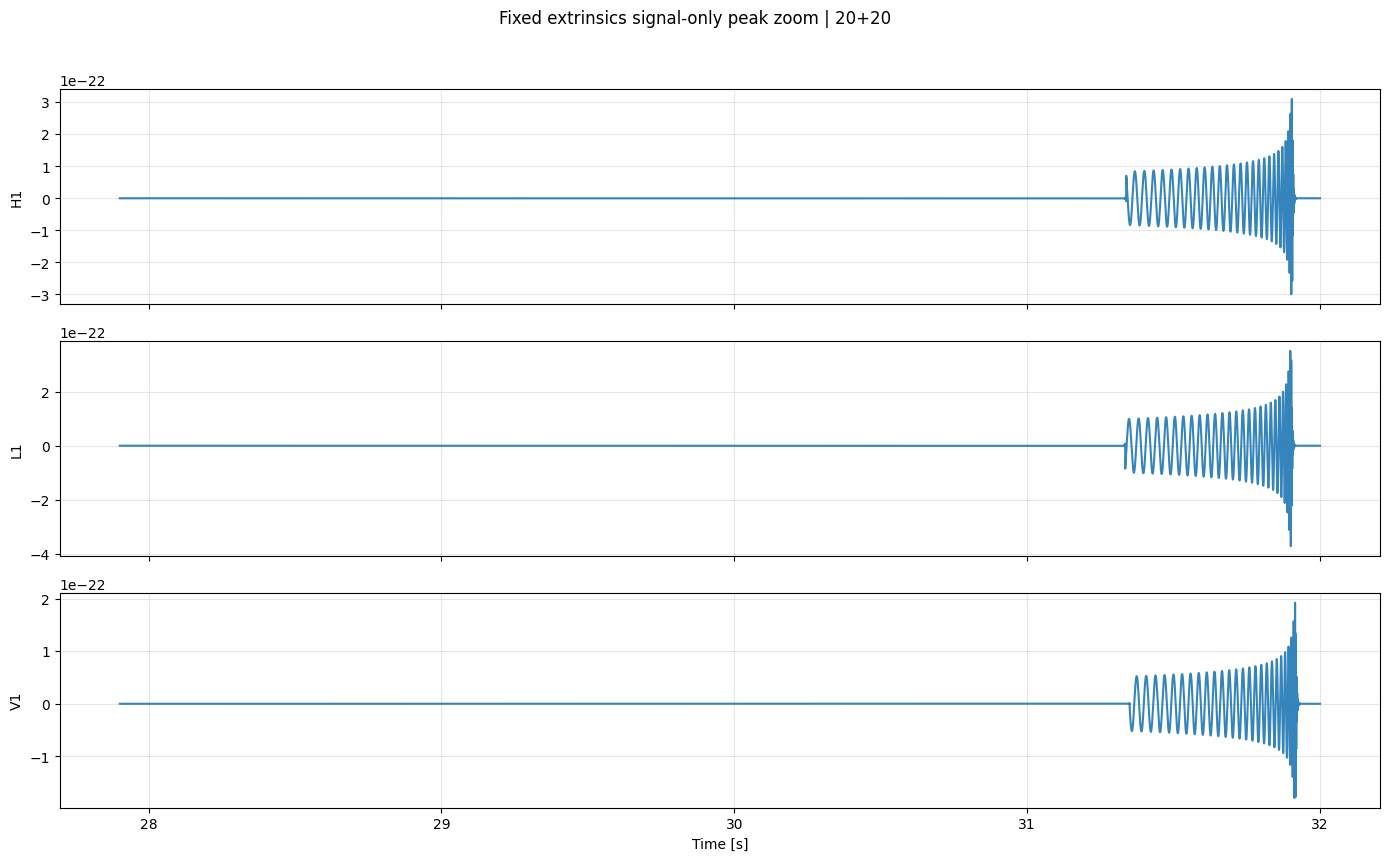

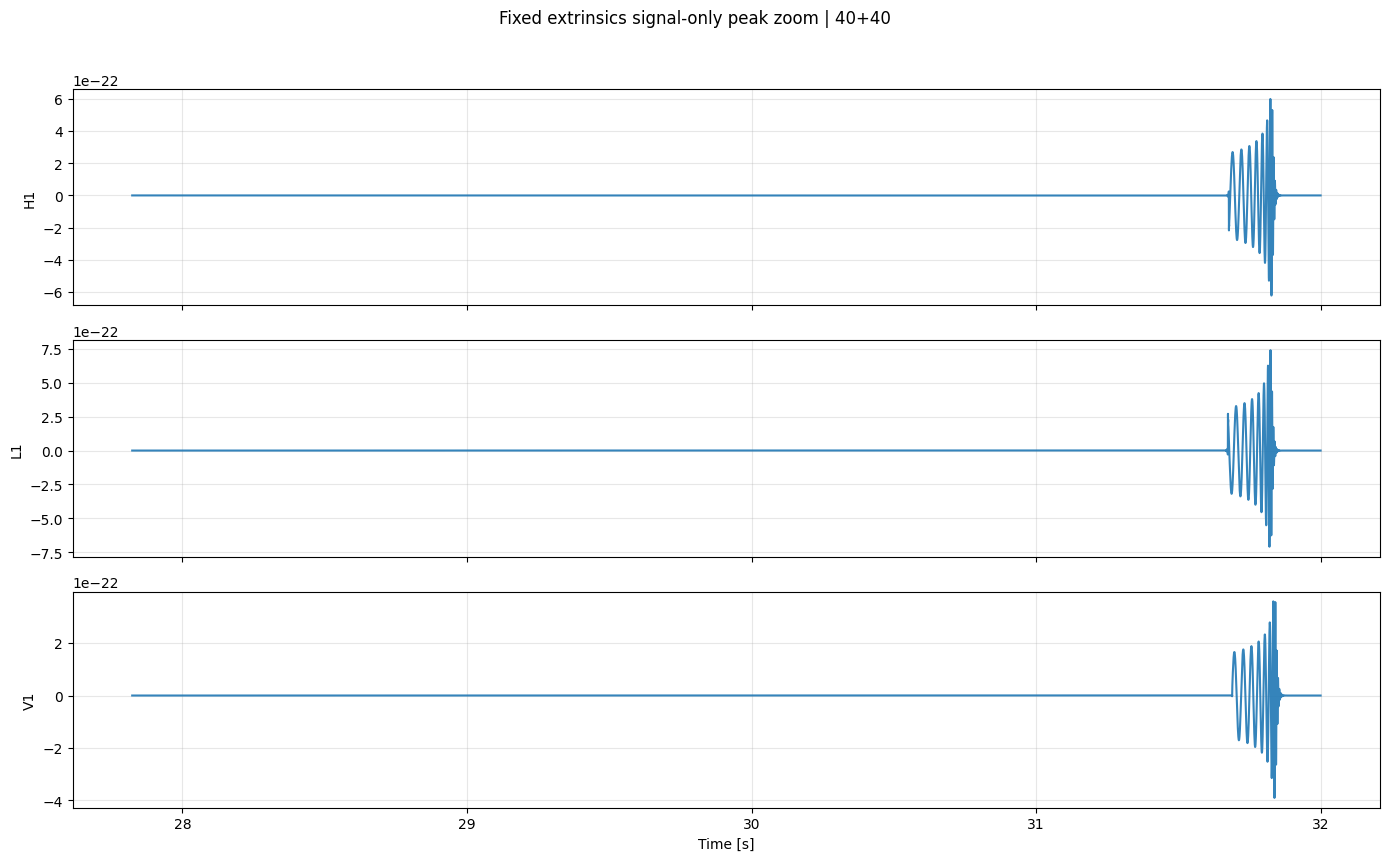

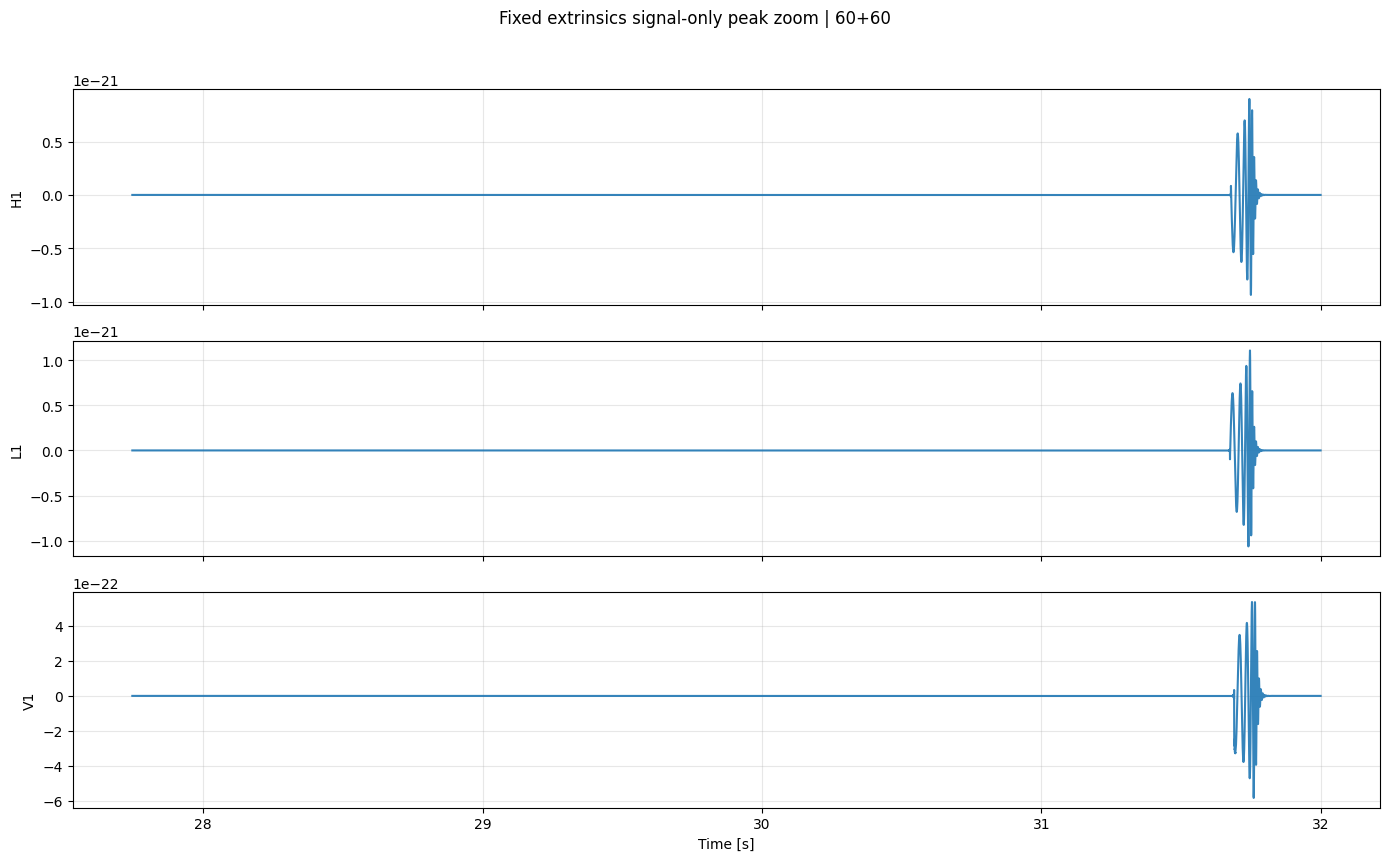

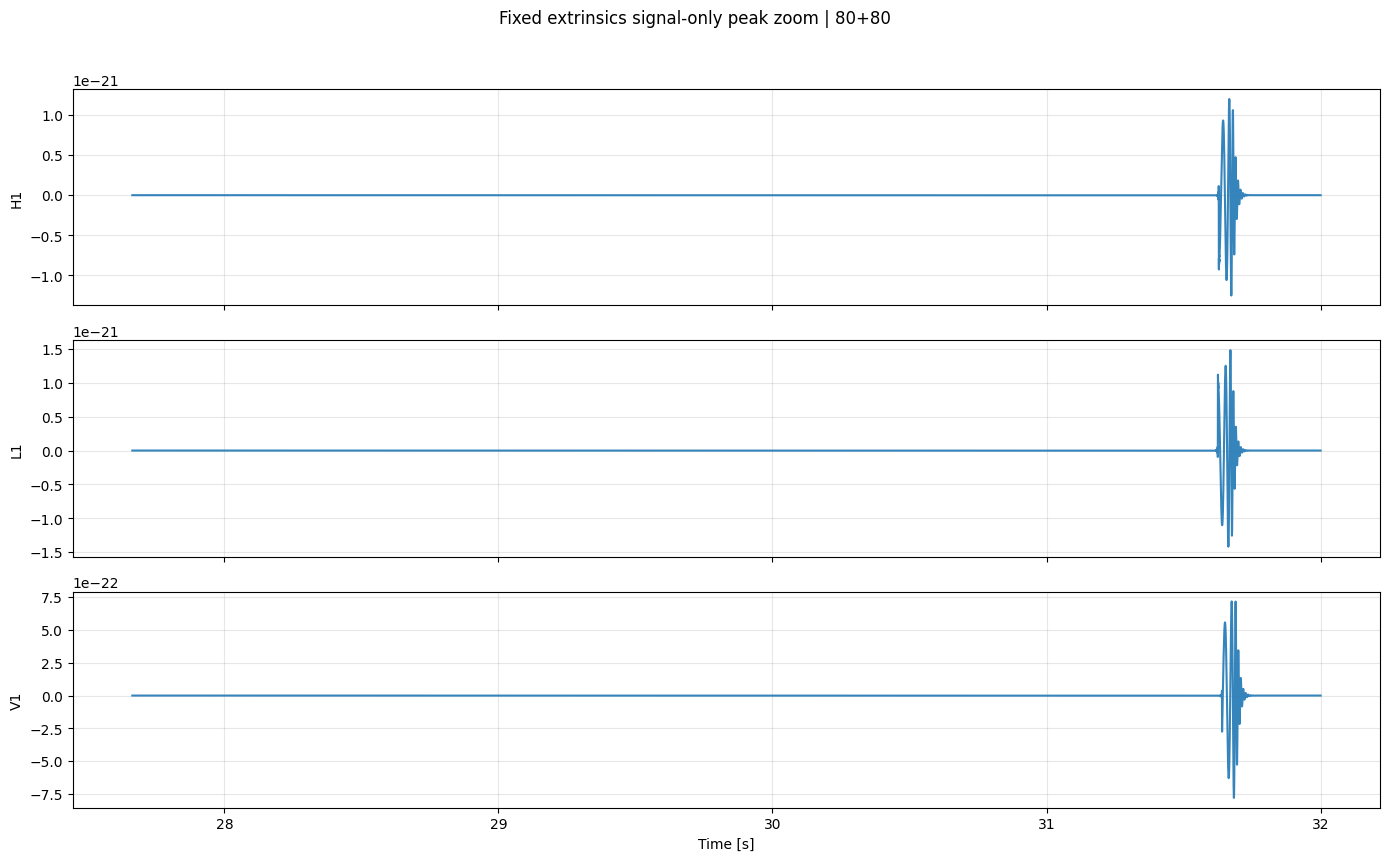

In [90]:
for i, mass in enumerate(fixed_labels):
    plot_network_peak_zoom(
        X_fixed,
        sample_idx=i,
        title=f"Fixed extrinsics signal-only peak zoom | {mass:.0f}+{mass:.0f}",
        fs=config.sampling_frequency,
        detector_names=detector_names,
        window_seconds=8.0,
    )

In [91]:
def rescale_signal_network_to_target_snr(X, current_snr, target_snr):
    """
    Rescale signal-only strain arrays so that their network SNR would match target_snr.

    Since SNR is linear in waveform amplitude, this is equivalent to multiplying
    the signal by target_snr / current_snr.
    """
    scale = target_snr / current_snr
    return X * scale

In [92]:
target_snr = 20.0

X_fixed_snr20 = []

for i in range(len(fixed_labels)):
    current_snr = fixed_meta_df.loc[i, "network_snr"]
    X_fixed_snr20.append(
        rescale_signal_network_to_target_snr(
            X_fixed[i],
            current_snr=current_snr,
            target_snr=target_snr,
        )
    )

X_fixed_snr20 = np.stack(X_fixed_snr20, axis=0)

print("X_fixed_snr20:", X_fixed_snr20.shape)

for i, mass in enumerate(fixed_labels):
    print(
        mass,
        "old snr:", fixed_meta_df.loc[i, "network_snr"],
        "scale:", target_snr / fixed_meta_df.loc[i, "network_snr"],
    )

X_fixed_snr20: (4, 3, 131072)
20.0 old snr: 27.937265083269576 scale: 0.7158896885714535
40.0 old snr: 47.51989914453678 scale: 0.420876314134588
60.0 old snr: 65.41002434894818 scale: 0.3057635308818167
80.0 old snr: 84.44287015571679 scale: 0.23684652076746113


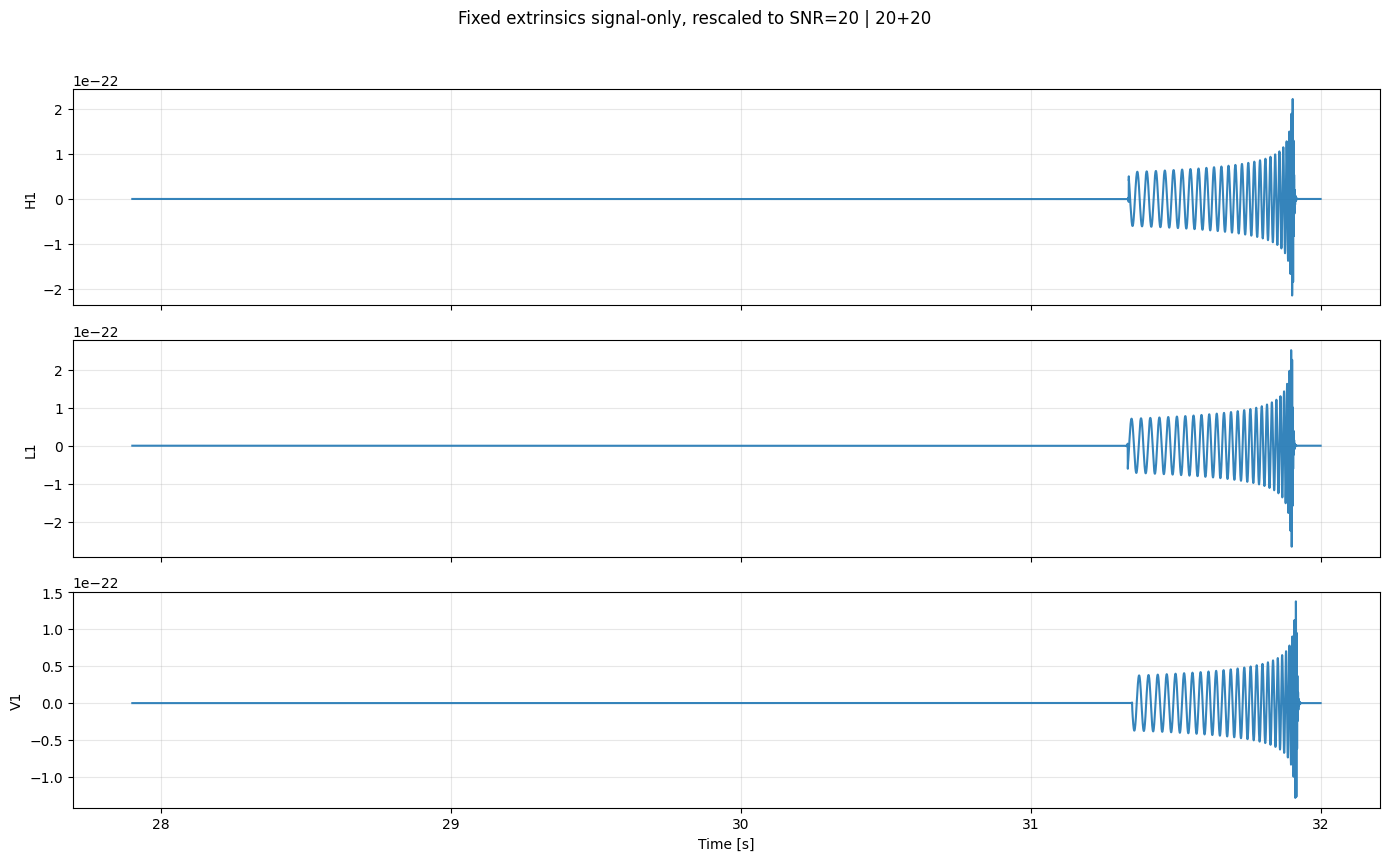

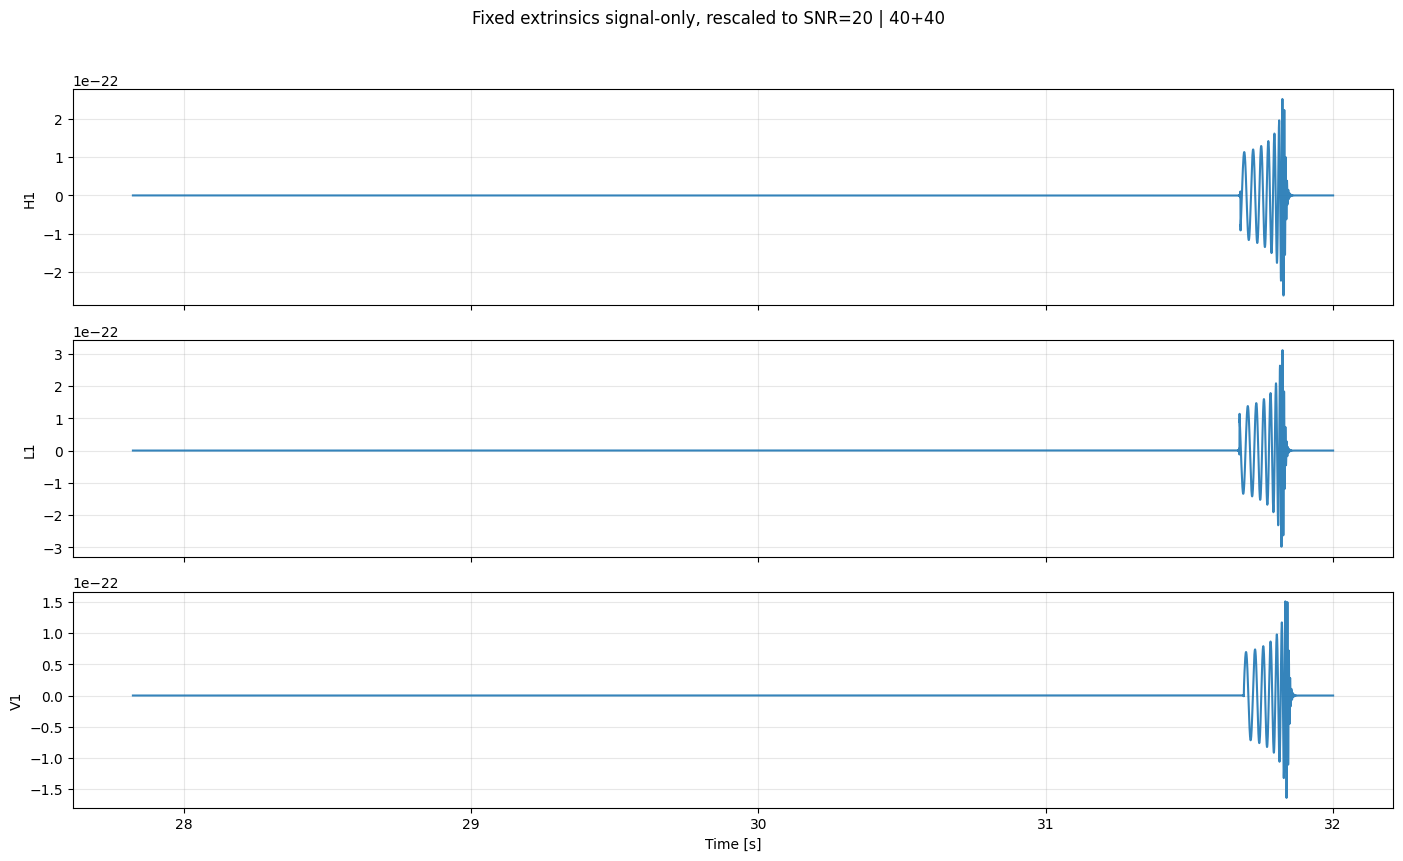

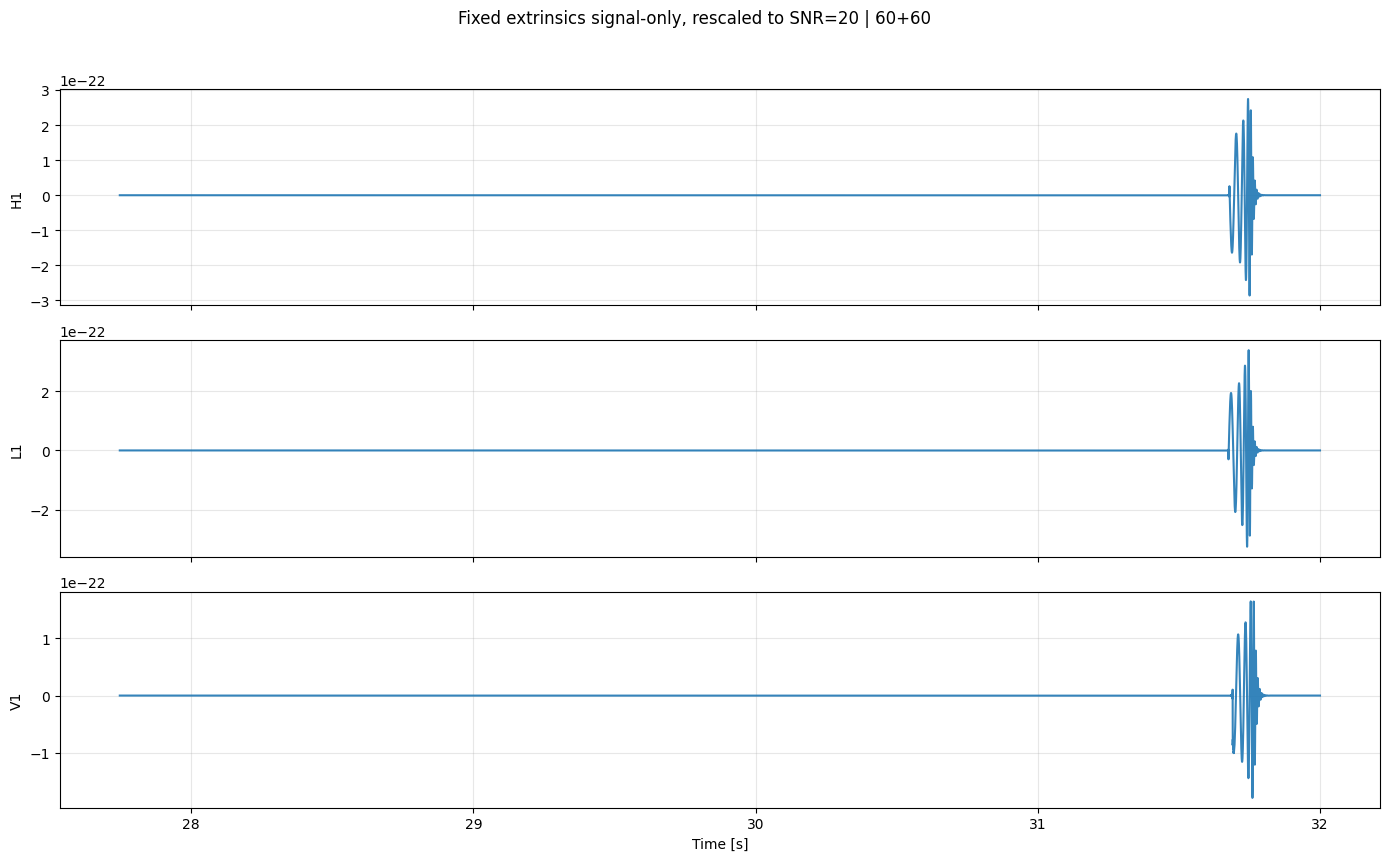

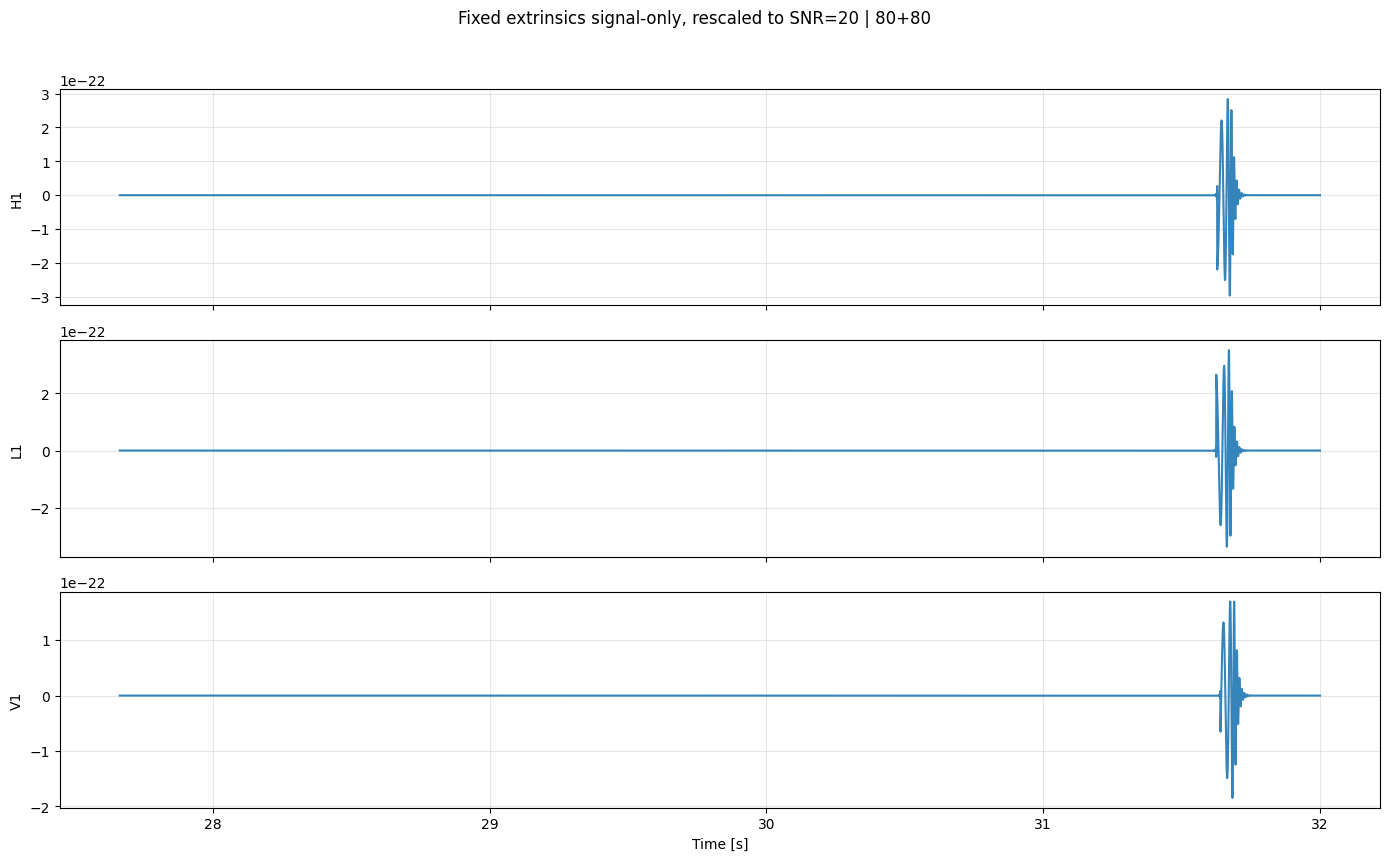

In [93]:
for i, mass in enumerate(fixed_labels):
    plot_network_peak_zoom(
        X_fixed_snr20,
        sample_idx=i,
        title=f"Fixed extrinsics signal-only, rescaled to SNR={target_snr:.0f} | {mass:.0f}+{mass:.0f}",
        fs=config.sampling_frequency,
        detector_names=detector_names,
        window_seconds=8.0,
    )

In [94]:
def signal_energy_profile(X, n_windows=64):
    """
    X shape: (n_samples, n_detectors, n_time)
    returns shape: (n_samples, n_windows)
    Network energy profile over time.
    """
    X64 = X.astype(np.float64)
    n, c, t = X64.shape

    usable = (t // n_windows) * n_windows
    X64 = X64[:, :, :usable]

    Xw = X64.reshape(n, c, n_windows, usable // n_windows)
    energy = np.sum(Xw**2, axis=(1, 3))  # sum over detectors and time inside window

    # Normalize each profile to sum to 1, so we compare shape not amplitude.
    energy = energy / energy.sum(axis=1, keepdims=True)

    return energy

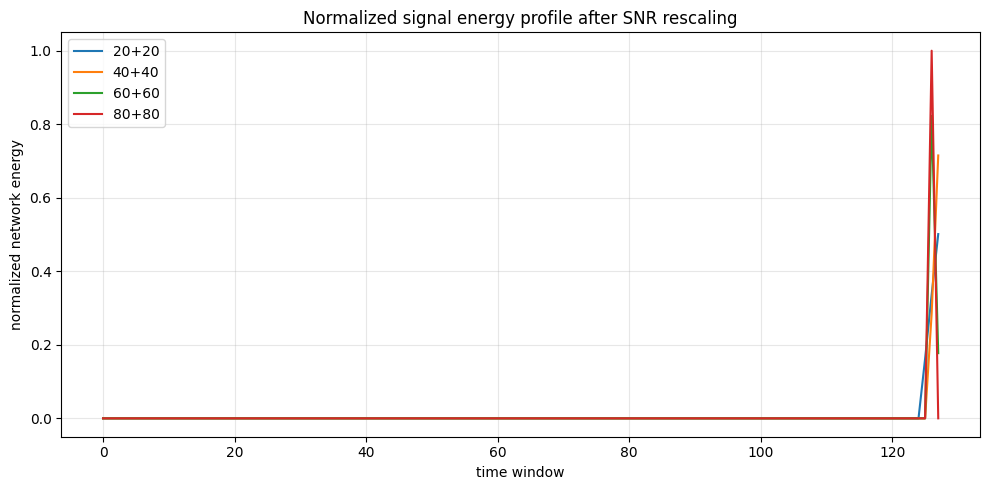

In [95]:
profiles = signal_energy_profile(X_fixed_snr20, n_windows=128)

plt.figure(figsize=(10, 5))

for i, mass in enumerate(fixed_labels):
    plt.plot(profiles[i], label=f"{mass:.0f}+{mass:.0f}")

plt.xlabel("time window")
plt.ylabel("normalized network energy")
plt.title("Normalized signal energy profile after SNR rescaling")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [96]:
def effective_energy_width(profile, threshold=0.90):
    """
    Number of windows needed to contain threshold fraction of total energy.
    Uses the smallest contiguous region around non-negligible energy approximately.
    """
    cumsum = np.cumsum(profile)

    widths = []

    for p in profile:
        pass

In [97]:
for i, mass in enumerate(fixed_labels):
    p = profiles[i]

    active_1pct = np.sum(p > 0.01 * p.max())
    active_5pct = np.sum(p > 0.05 * p.max())

    print(f"{mass:.0f}+{mass:.0f}")
    print("  windows > 1% max:", active_1pct)
    print("  windows > 5% max:", active_5pct)

20+20
  windows > 1% max: 3
  windows > 5% max: 3
40+40
  windows > 1% max: 2
  windows > 5% max: 2
60+60
  windows > 1% max: 2
  windows > 5% max: 2
80+80
  windows > 1% max: 1
  windows > 5% max: 1


## Parameters variables

In [98]:
def normalized_energy_profiles(X, n_windows=128):
    """
    Compute normalized network energy profiles.

    X shape: (n_samples, n_detectors, n_time)
    returns shape: (n_samples, n_windows)
    """
    X64 = X.astype(np.float64)
    n, c, t = X64.shape

    usable = (t // n_windows) * n_windows
    X64 = X64[:, :, :usable]

    Xw = X64.reshape(n, c, n_windows, usable // n_windows)
    energy = np.sum(Xw**2, axis=(1, 3))

    total = energy.sum(axis=1, keepdims=True)
    if np.any(total <= 0):
        bad = np.where(total.reshape(-1) <= 0)[0]
        raise ValueError(f"Found zero-energy samples: {bad}")

    return energy / total

In [99]:
profiles_var = normalized_energy_profiles(X_signal, n_windows=128)

profile_df = pd.DataFrame(profiles_var)
profile_df["mass_group"] = all_mass_labels

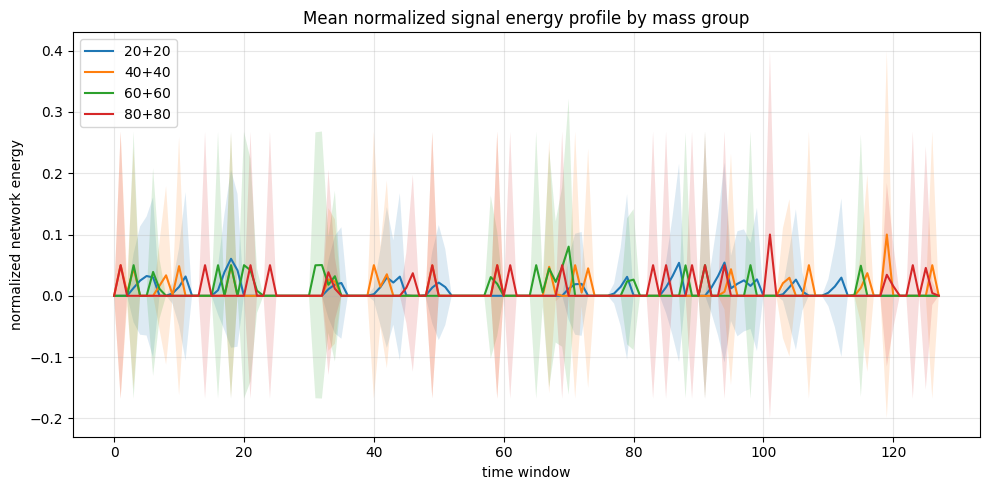

In [100]:
plt.figure(figsize=(10, 5))

for mass in mass_groups:
    p = profiles_var[all_mass_labels == mass]
    mean_p = p.mean(axis=0)
    std_p = p.std(axis=0)

    x = np.arange(mean_p.shape[0])
    plt.plot(x, mean_p, label=f"{mass:.0f}+{mass:.0f}")
    plt.fill_between(x, mean_p - std_p, mean_p + std_p, alpha=0.15)

plt.xlabel("time window")
plt.ylabel("normalized network energy")
plt.title("Mean normalized signal energy profile by mass group")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
active_rows = []

for i, mass in enumerate(all_mass_labels):
    p = profiles_var[i]

    active_rows.append({
        "mass_group": mass,
        "active_1pct": np.sum(p > 0.01 * p.max()),
        "active_5pct": np.sum(p > 0.05 * p.max()),
        "peak_window": int(np.argmax(p)),
    })

active_df = pd.DataFrame(active_rows)

active_df.groupby("mass_group")[["active_1pct", "active_5pct", "peak_window"]].describe()

active_1pct                                           active_5pct  \
                 count  mean       std  min  25%  50%   75%  max       count   
mass_group                                                                     
20.0              20.0  3.25  0.444262  3.0  3.0  3.0  3.25  4.0        20.0   
40.0              20.0  1.55  0.510418  1.0  1.0  2.0  2.00  2.0        20.0   
60.0              20.0  1.50  0.512989  1.0  1.0  1.5  2.00  2.0        20.0   
80.0              20.0  1.20  0.410391  1.0  1.0  1.0  1.00  2.0        20.0   

                  ...           peak_window                                \
            mean  ...  75%  max       count   mean        std  min    25%   
mass_group        ...                                                       
20.0        3.10  ...  3.0  4.0        20.0  58.65  37.464755  4.0  19.00   
40.0        1.45  ...  2.0  2.0        20.0  63.00  43.076431  1.0  29.25   
60.0        1.45  ...  2.0  2.0        20.0  52.60  33.375692  3.0  20.75   
80.0        1.20  ...  1.0  2.0        20.0  69.40  37.644319  1.0  42.75   

                                 
             50%     75%    max  
mass_group                       
20.0        61.0   94.00  112.0  
40.0        63.0  104.75  126.0  
60.0        61.5   72.50  115.0  
80.0        76.0   95.75  125.0  

[4 rows x 24 columns]

## Alineamiento de los peaks

In [102]:
def align_profiles_by_peak(profiles, target_peak=None):
    """
    Circularly shift each profile so that its peak is at target_peak.
    """
    n_samples, n_windows = profiles.shape

    if target_peak is None:
        target_peak = n_windows // 2

    aligned = np.zeros_like(profiles)
    original_peaks = np.argmax(profiles, axis=1)

    for i in range(n_samples):
        shift = target_peak - original_peaks[i]
        aligned[i] = np.roll(profiles[i], shift)

    return aligned, original_peaks

In [103]:
profiles_aligned, original_peaks = align_profiles_by_peak(
    profiles_var,
    target_peak=64,
)

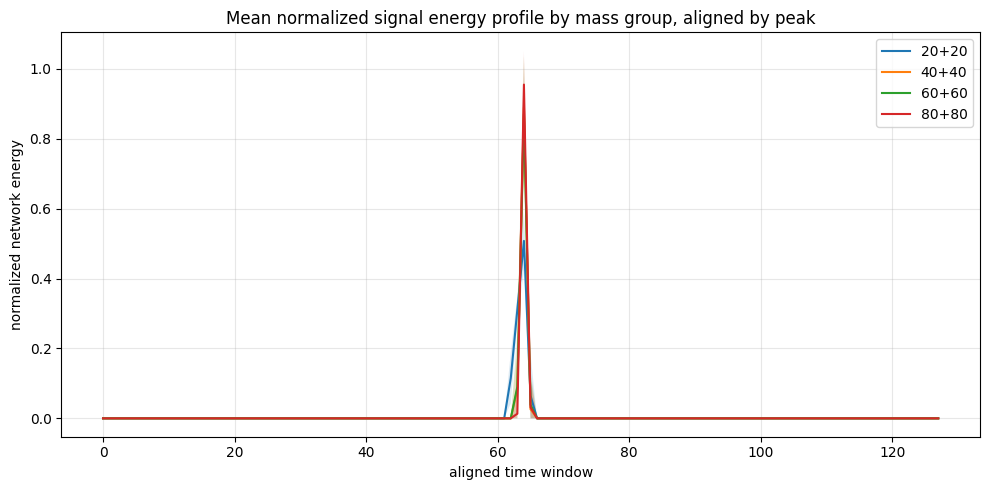

In [104]:
plt.figure(figsize=(10, 5))

for mass in mass_groups:
    p = profiles_aligned[all_mass_labels == mass]
    mean_p = p.mean(axis=0)
    std_p = p.std(axis=0)

    x = np.arange(mean_p.shape[0])

    lower = np.maximum(mean_p - std_p, 0.0)
    upper = mean_p + std_p

    plt.plot(x, mean_p, label=f"{mass:.0f}+{mass:.0f}")
    plt.fill_between(x, lower, upper, alpha=0.15)

plt.xlabel("aligned time window")
plt.ylabel("normalized network energy")
plt.title("Mean normalized signal energy profile by mass group, aligned by peak")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_615850/3590266095.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"{int(m)}+{int(m)}" for m in mass_groups])


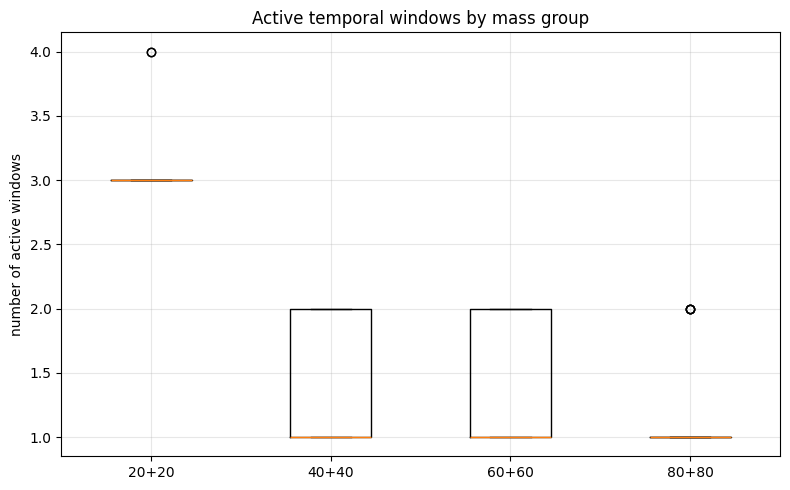

In [105]:
plt.figure(figsize=(8, 5))

data = [
    active_df.loc[active_df["mass_group"] == mass, "active_5pct"].values
    for mass in mass_groups
]

plt.boxplot(data, labels=[f"{int(m)}+{int(m)}" for m in mass_groups])
plt.ylabel("number of active windows")
plt.title("Active temporal windows by mass group")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_615850/1055182977.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"{int(m)}+{int(m)}" for m in mass_groups])


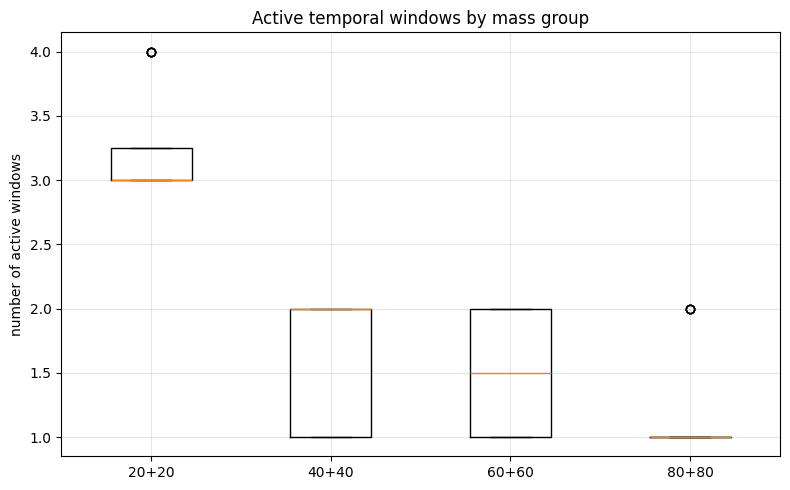

In [106]:
plt.figure(figsize=(8, 5))

data = [
    active_df.loc[active_df["mass_group"] == mass, "active_1pct"].values
    for mass in mass_groups
]

plt.boxplot(data, labels=[f"{int(m)}+{int(m)}" for m in mass_groups])
plt.ylabel("number of active windows")
plt.title("Active temporal windows by mass group")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()